In [2]:
import numpy as np
import pandas as pd
import math
import textwrap

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

from scipy import stats
from scipy.stats import t, gmean
from itertools import combinations


In [3]:
### Setting global plot features — Publication Style ###

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator, LogLocator, NullFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.style.use('default')

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "font.weight": "normal",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "axes.labelcolor": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
        "xtick.color": "black",
    "ytick.color": "black",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "text.color": "black",
    "figure.facecolor": "white",
    "figure.dpi": 150,
    "legend.frameon": True,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "#cccccc",
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "legend.facecolor": "white",
    "lines.linewidth": 1.8,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

FIT_LINE_COLOR   = "#B03A2E"
RMSE_BAND_COLOR  = "#64A082"
GM_MARKER_COLOR  = "#B07D2A"
REMOVED_PT_COLOR = "#A0293D"
OBS_COLOR        = "#1B3A5C"
REF_LINE_COLOR   = "#B07D2A"

CAP_CLASS_COLORS = {
    "Small":  {"face": "#1B3A5C", "alpha_box": 0.28, "alpha_border": 0.70},
    "Medium": {"face": "#3D6B45", "alpha_box": 0.28, "alpha_border": 0.70},
    "Large":  {"face": "#7A1A2E", "alpha_box": 0.20, "alpha_border": 0.55},
}


In [39]:
def _wrap_label(text, width=12):
    """Wrap long labels onto multiple lines to avoid overlap."""
    return "\n".join(textwrap.wrap(text, width=width)) if len(text) > width else text


SUBTYPE_STYLES = {'Nutsche Filters': {'color': '#2C5F8A', 'marker': 'o', 'linestyle': '-'}, 'Rotary Drum Filters': {'color': '#1D7D5A', 'marker': '^', 'linestyle': '--'}, 'Plate & Frame Filters': {'color': '#A0293D', 'marker': 's', 'linestyle': ':'}}



def plot_pv_histogram(df, column_name, equipment, unit, bins):
    """Histogram of power intensity — publication style."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, col, label in zip(
        axes,
        [column_name.replace('log(','').replace(')',''), column_name],
        ['(a) Raw', '(b) Log\u2081\u2080-transformed']
    ):
        if col not in df.columns:
            col = column_name
        data = df[col].dropna()
        b = freedman_diaconis_bins(data)
        ax.hist(data, bins=b, color='#1B3A5C', alpha=0.55,
                edgecolor='#1B3A5C', linewidth=0.4)
        ax.set_xlabel(f"Power intensity [kW·m$^{-2}$]", style='italic', fontsize=10)
        ax.set_ylabel('Count', style='italic', fontsize=10)
        ax.set_title(label, fontsize=10, color='black', style='italic', pad=4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    fig.suptitle(f'Power intensity distribution — {equipment}',
                 fontsize=11, color='black', y=1.01)
    plt.tight_layout()
    plt.show()



def plot_equipment_type_distribution(df, equipment_type="Equipment"):
    """Bar chart of subtype counts — publication style."""
    type_counts = df["Type"].value_counts().sort_values(ascending=False)
    bin_labels = type_counts.index.tolist()
    counts = type_counts.values.tolist()
    x = np.arange(len(bin_labels))
    bar_colors = [SUBTYPE_STYLES.get(t, {}).get("color", "#1B3A5C") for t in bin_labels]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(x, counts, color=bar_colors, alpha=0.60,
                  edgecolor=bar_colors, linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, str(count),
                ha='center', va='bottom', fontsize=9, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels([_wrap_label(t, width=10) for t in bin_labels], rotation=0, ha='center', fontsize=9)
    ax.set_xlabel(f"{equipment_type} sub-types", style='italic', fontsize=10)
    ax.set_ylabel(f"Number of {equipment_type}", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ymax = math.ceil(max(counts) * 1.18 / 10) * 10
    ax.set_ylim(0, ymax)
    plt.tight_layout()
    plt.show()



def plot_pa_vs_a_by_type(df, type_color_map, equipment_type="Equipment"):
    """Scatter P/capacity by subtype — approved color+shape, no fit lines, power scale."""
    unique_types = df["Type"].unique()
    fig, ax = plt.subplots(figsize=(8, 6))
    legend_handles = []
    for t in unique_types:
        st = SUBTYPE_STYLES.get(t, {"color": "#333333", "marker": "o"})
        subset = df[df["Type"] == t]
        ax.scatter(subset["Area_m²"], subset["PowerToCapacity_kW·m⁻²"],
                   color=st["color"], marker=st["marker"],
                   s=18, alpha=0.68, edgecolors=st["color"], linewidths=0.3, zorder=2)
        legend_handles.append(Line2D([0],[0], marker=st["marker"], color='w',
                   markerfacecolor=st["color"], markeredgecolor=st["color"],
                   markersize=6, label=t))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Area [m$^2$]", style='italic', fontsize=10)
    ax.set_ylabel("Power intensity [kW·m$^{-2}$]", style='italic', fontsize=10)
    ax.legend(handles=legend_handles, title=f"{equipment_type} sub-types",
              fontsize=8, title_fontsize=9, frameon=True,
              facecolor='white', edgecolor='#cccccc', loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()



def plot_logpa_vs_loga_by_type(df, type_color_map, equipment_type="Equipment"):
    """Scatter log(P/capacity) vs log(capacity) — approved color+shape, no fit lines."""
    unique_types = df["Type"].unique()
    fig, ax = plt.subplots(figsize=(8, 6))
    legend_handles = []
    for t in unique_types:
        st = SUBTYPE_STYLES.get(t, {"color": "#333333", "marker": "o"})
        subset = df[df["Type"] == t]
        ax.scatter(subset["log(Capacity)"], subset["log(PowerToCapacity)"],
                   color=st["color"], marker=st["marker"],
                   s=18, alpha=0.68, edgecolors=st["color"], linewidths=0.3, zorder=2)
        legend_handles.append(Line2D([0],[0], marker=st["marker"], color='w',
                   markerfacecolor=st["color"], markeredgecolor=st["color"],
                   markersize=6, label=t))
    ax.set_xlabel("log(A)  [m$^2$]", style='italic', fontsize=10)
    ax.set_ylabel("log(P/A)  [kW·m$^{-2}$]", style='italic', fontsize=10)
    ax.legend(handles=legend_handles, title=f"{equipment_type} sub-types",
              fontsize=8, title_fontsize=9, frameon=True,
              facecolor='white', edgecolor='#cccccc', loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()



def _diag_scatter(ax, obs_x, normal_mask, diag_vals, threshold_vals,
                  ylabel, zero_line=False, thresh_label="Threshold"):
    """Shared helper for influence diagnostic subplots."""
    THRESH_COLOR = '#B07D2A'
    ax.scatter(obs_x[normal_mask], diag_vals[normal_mask],
               color=OBS_COLOR, alpha=0.65, s=12, linewidths=0.3,
               edgecolors=OBS_COLOR, zorder=2)
    infl = ~normal_mask
    if infl.any():
        ax.scatter(obs_x[infl], diag_vals[infl],
                   color=REMOVED_PT_COLOR, alpha=0.95, s=12,
                   marker='D', linewidths=0.4, edgecolors=REMOVED_PT_COLOR, zorder=3)
    if isinstance(threshold_vals, (list, tuple)):
        for tv in threshold_vals:
            ax.axhline(tv, color=THRESH_COLOR, linewidth=1.1, linestyle='--', zorder=1)
    else:
        ax.axhline(threshold_vals, color=THRESH_COLOR, linewidth=1.1, linestyle='--', zorder=1)
    if zero_line:
        ax.axhline(0, color='#cccccc', linewidth=0.6, zorder=1)
    ax.set_ylabel(ylabel, style='italic', fontsize=10)
    ax.set_xlabel('Observation number', style='italic', fontsize=10)
    ax.tick_params(axis='both', labelsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    th_handle = Line2D([0],[0], color=THRESH_COLOR, linewidth=1.1, linestyle='--',
                       label=thresh_label)
    leg = ax.legend(handles=[th_handle], fontsize=8, frameon=True,
                    facecolor='white', edgecolor='#cccccc',
                    loc='lower right', bbox_to_anchor=(1.0, 1.01),
                    handletextpad=0.4, borderpad=0.35)
    leg.set_zorder(5)


def plot_leverage(df_influence, equipment_type, id_col="Entry_No.", mean_lev=None):
    """2x2 influence diagnostics — publication style."""
    obs = df_influence[id_col].values if id_col in df_influence.columns else np.arange(len(df_influence))
    lev = df_influence["Leverage"].values; sr = df_influence["StudResid"].values
    dff = df_influence["DFFITS"].values; cks = df_influence["CooksD"].values
    n = len(obs); k = 1
    if mean_lev is None: mean_lev = lev.mean()
    lev_thresh = 3*mean_lev; dff_thresh = 2*np.sqrt((k+2)/(n-k-2)); cks_thresh = 4/n
    fig, axes = plt.subplots(2, 2, figsize=(6.5, 4.8))
    fig.suptitle(f'Influence diagnostics — {equipment_type}',
                 fontsize=11, color='#333333', y=1.00)
    _diag_scatter(axes[0,0], obs, lev <= lev_thresh, lev, lev_thresh, 'Leverage',
                  thresh_label=f'Threshold = 3 × mean leverage = {lev_thresh:.4f}')
    _diag_scatter(axes[0,1], obs, np.abs(sr) < 3, sr, [-3, 3],
                  'Studentized residual', zero_line=True, thresh_label='Threshold = ±3')
    _diag_scatter(axes[1,0], obs, np.abs(dff) < dff_thresh, dff, [-dff_thresh, dff_thresh],
                  'DFFITS', zero_line=True,
                  thresh_label=f'Threshold = 2√((k+2)/(n−k−2)) = ±{dff_thresh:.3f}')
    _diag_scatter(axes[1,1], obs, cks <= cks_thresh, cks, cks_thresh, "Cook's distance",
                  thresh_label=f'Threshold = 4/n = {cks_thresh:.4f}')
    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=OBS_COLOR,
               markersize=5, label='Normal observation'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=REMOVED_PT_COLOR,
               markersize=5, label='Influential observation'),
    ]
    fig.legend(handles=legend_els, loc='lower center', ncol=2, fontsize=8,
               frameon=True, facecolor='white', edgecolor='#cccccc', bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout(h_pad=2.3, w_pad=1.5)
    plt.show()


def plot_fit_unified(df, x_col, y_col, df_coefs, df_model,
                     equipment_type="", capacity_type="A",
                     loglog=True, df_influential=None):
    """Log-log or power-scale fit plot — publication style."""
    coefs    = df_coefs["Coefficient"].astype(float).values
    rmse_log = float(df_model["RMSE"].iloc[0])
    r2adj    = float(df_model["R2_adj"].iloc[0])
    x = df[x_col].values; y = df[y_col].values
    terms = []
    for i, c in enumerate(coefs):
        if i == 0: terms.append(f"{c:.4f}")
        elif i == 1: terms.append(f"{c:+.4f} log(A)")
        else: terms.append(f"{c:+.4f} log(A)^{i}")
    eq_str = " ".join(terms)

    if loglog:
        x_sorted = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        y_fit = sum(c * x_sorted**i for i, c in enumerate(coefs))
        fig, ax = plt.subplots(figsize=(7, 5.5))
        ax.fill_between(x_sorted, y_fit - rmse_log, y_fit + rmse_log,
                        color=RMSE_BAND_COLOR, alpha=0.20, zorder=1)
        ax.plot(x_sorted, y_fit + rmse_log, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
        ax.plot(x_sorted, y_fit - rmse_log, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
        ax.scatter(x, y, color=OBS_COLOR, s=12, alpha=0.60, edgecolors=OBS_COLOR, linewidths=0.3, zorder=3)
        if df_influential is not None and not df_influential.empty:
            if x_col in df_influential.columns and y_col in df_influential.columns:
                ax.scatter(df_influential[x_col], df_influential[y_col],
                           color=REMOVED_PT_COLOR, marker='D', s=35, alpha=0.85,
                           edgecolors=REMOVED_PT_COLOR, linewidths=0.4, zorder=4,
                           label='Removed influential points')
        ax.plot(x_sorted, y_fit, color=FIT_LINE_COLOR, linewidth=2.0, zorder=5)
        ax.set_xlabel(f"log(A)  [m$^2$]", style='italic', fontsize=10)
        ax.set_ylabel("log(P/A)  [kW·m$^{-2}$]", style='italic', fontsize=10)
        legend_els = [
            Line2D([0],[0], marker='o', color='w', markerfacecolor=OBS_COLOR, markersize=6, label='Observations'),
            Line2D([0],[0], marker='D', color='w', markerfacecolor=REMOVED_PT_COLOR, markersize=6, label='Removed points'),
            Line2D([0],[0], color=FIT_LINE_COLOR, linewidth=2, label='OLS fit'),
            Patch(facecolor=RMSE_BAND_COLOR, alpha=0.35, label=f'\u00b1RMSE ({rmse_log:.4f})'),
        ]
        ax.legend(handles=legend_els, fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
        ax.text(0.03, 0.05,
                f"log(P/A) = {eq_str}\n$R^2_{{adj}}$ = {r2adj:.4f}",
                transform=ax.transAxes, fontsize=8.5, color='black', verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8', edgecolor='#dddddd', alpha=0.9))
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        plt.tight_layout(); plt.show()
        return

    # RAW scale
    mask_pos = (x > 0) & (y > 0)
    x_pos, y_pos = x[mask_pos], y[mask_pos]
    x_sorted = np.logspace(np.log10(x_pos.min()), np.log10(x_pos.max()), 200)
    logx_s   = np.log10(x_sorted)
    y_fit    = 10 ** sum(c * logx_s**i for i, c in enumerate(coefs))
    mult     = 10 ** rmse_log
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.fill_between(x_sorted, y_fit / mult, y_fit * mult,
                    color=RMSE_BAND_COLOR, alpha=0.20, zorder=1)
    ax.plot(x_sorted, y_fit * mult, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
    ax.plot(x_sorted, y_fit / mult, color=RMSE_BAND_COLOR, linewidth=0.7, linestyle='--', alpha=0.55, zorder=2)
    ax.scatter(x, y, color=OBS_COLOR, s=12, alpha=0.60, edgecolors=OBS_COLOR, linewidths=0.3, zorder=3)
    if df_influential is not None and not df_influential.empty:
        if x_col in df_influential.columns and y_col in df_influential.columns:
            ax.scatter(df_influential[x_col], df_influential[y_col],
                       color=REMOVED_PT_COLOR, marker='D', s=35, alpha=0.85,
                       edgecolors=REMOVED_PT_COLOR, linewidths=0.4, zorder=4)
    ax.plot(x_sorted, y_fit, color=FIT_LINE_COLOR, linewidth=2.0, zorder=5)
    ax.set_xlabel("Area [m$^2$]", style='italic', fontsize=10)
    ax.set_ylabel("Power intensity [kW·m$^{-2}$]", style='italic', fontsize=10)
    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=OBS_COLOR, markersize=6, label='Observations'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=REMOVED_PT_COLOR, markersize=6, label='Removed points'),
        Line2D([0],[0], color=FIT_LINE_COLOR, linewidth=2, label='OLS fit'),
        Patch(facecolor=RMSE_BAND_COLOR, alpha=0.35, label='RMSE interval'),
    ]
    ax.legend(handles=legend_els, fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
    ax.text(0.03, 0.05,
            f"P/A = 10^({eq_str})\n$R^2_{{adj}}$ = {r2adj:.4f}",
            transform=ax.transAxes, fontsize=8.5, color='black', verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8', edgecolor='#dddddd', alpha=0.9))
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()

#─────────────────────────────────────────────────────────────────────────────────────────────────────────#

def plot_fit_multi_type_raw_unified(df, x_col, y_col, degrees_by_type, type_color_map,
                                    all_coeffs_df, all_models_df=None,
                                    equipment_type="Equipment", capacity_type="A"):
    """Multi-subtype power-scale scatter + fit curves."""
    unique_types = df["Type"].unique()
    fig, ax = plt.subplots(figsize=(8, 6))
    legend_handles = []
    for eq_type in unique_types:
        st = SUBTYPE_STYLES.get(eq_type, {"color":"#333","marker":"o","linestyle":"-"})
        df_sub = df[df["Type"] == eq_type].copy()
        df_c   = all_coeffs_df[all_coeffs_df["Type"] == eq_type]
        if df_c.empty: continue
        coefs = df_c["Coefficient"].astype(float).values
        x = df_sub[x_col].values; y = df_sub[y_col].values
        mask_pos = (x > 0) & (y > 0)
        x_pos, y_pos = x[mask_pos], y[mask_pos]
        if x_pos.size == 0: continue
        x_sorted = np.logspace(np.log10(x_pos.min()), np.log10(x_pos.max()), 200)
        y_fit = 10 ** sum(c * np.log10(x_sorted)**i for i, c in enumerate(coefs))
        ax.scatter(x_pos, y_pos, color=st["color"], marker=st["marker"],
                   s=18, alpha=0.68, edgecolors=st["color"], linewidths=0.3, zorder=2)
        ax.plot(x_sorted, y_fit, color=st["color"], linestyle=st["linestyle"], linewidth=1.8, zorder=3)
        legend_handles.append(Line2D([0],[0], marker=st["marker"], color=st["color"],
                   markerfacecolor=st["color"], markersize=5,
                   linestyle=st["linestyle"], linewidth=1.5, label=eq_type))
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("Area [m$^2$]", style='italic', fontsize=10)
    ax.set_ylabel("Power intensity [kW·m$^{-2}$]", style='italic', fontsize=10)
    ax.legend(handles=legend_handles, title=f"{equipment_type} sub-types",
              fontsize=8, title_fontsize=9, frameon=True, facecolor='white', edgecolor='#cccccc')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # --- Per-subtype equations underneath the plot ---
    fig.subplots_adjust(bottom=0.05 + 0.045 * len(unique_types))
    for i, eq_type in enumerate(unique_types):
        st = SUBTYPE_STYLES.get(eq_type, {"color": "#333"})
        df_c = all_coeffs_df[all_coeffs_df["Type"] == eq_type]
        if df_c.empty:
            continue
        coefs = df_c["Coefficient"].astype(float).values
        terms = [f"{coefs[0]:.4f}"] + [
            f"{c:+.4f}\u00b7log({capacity_type})" + (f"^{j}" if j > 1 else "")
            for j, c in enumerate(coefs[1:], start=1)
        ]
        eq_text = f"{eq_type}: log(P/{capacity_type}) = " + " ".join(terms)
        fig.text(0.5, 0.03 + 0.045 * (len(unique_types) - 1 - i), eq_text,
                  ha='center', fontsize=8, color=st["color"],
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor=st["color"], linewidth=1.0))

    plt.show()

#─────────────────────────────────────────────────────────────────────────────────────────────────────────#

def plot_fit_multi_type(df, x_col, y_col, degrees_by_type, type_color_map,
                        equipment_type="Equipment", capacity_type="A"):
    """Multi-subtype log-log scatter + fit lines."""
    unique_types = df["Type"].unique()
    fig, ax = plt.subplots(figsize=(8, 6))
    legend_handles = []
    for t in unique_types:
        st = SUBTYPE_STYLES.get(t, {"color":"#333","marker":"o","linestyle":"-"})
        df_sub = df[df["Type"] == t]
        degree = degrees_by_type.get(t, 1)
        x = df_sub[x_col].values; y = df_sub[y_col].values
        X_poly = np.vander(x, degree + 1, increasing=True)
        model  = sm.OLS(y, X_poly).fit()
        coefs  = model.params
        x_sorted = np.linspace(x.min(), x.max(), 200)
        y_fit = sum(c * x_sorted**i for i, c in enumerate(coefs))
        ax.scatter(x, y, color=st["color"], marker=st["marker"],
                   s=18, alpha=0.68, edgecolors=st["color"], linewidths=0.3, zorder=2)
        ax.plot(x_sorted, y_fit, color=st["color"], linestyle=st["linestyle"], linewidth=1.8, zorder=3)
        legend_handles.append(Line2D([0],[0], marker=st["marker"], color=st["color"],
                   markerfacecolor=st["color"], markersize=5,
                   linestyle=st["linestyle"], linewidth=1.5, label=t))
    ax.set_xlabel("log(A)  [m$^2$]", style='italic', fontsize=10)
    ax.set_ylabel("log(P/A)  [kW·m$^{-2}$]", style='italic', fontsize=10)
    ax.legend(handles=legend_handles, title=f"{equipment_type} sub-types",
              fontsize=8, title_fontsize=9, frameon=True, facecolor='white', edgecolor='#cccccc')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # --- Per-subtype equations underneath the plot ---
    fig.subplots_adjust(bottom=0.05 + 0.045 * len(unique_types))
    for i, t in enumerate(unique_types):
        st = SUBTYPE_STYLES.get(t, {"color": "#333"})
        df_sub = df[df["Type"] == t]
        degree = degrees_by_type.get(t, 1)
        x = df_sub[x_col].values; y = df_sub[y_col].values
        X_poly = np.vander(x, degree + 1, increasing=True)
        model  = sm.OLS(y, X_poly).fit()
        coefs  = model.params
        terms = [f"{coefs[0]:.4f}"] + [
            f"{c:+.4f}\u00b7log({capacity_type})" + (f"^{j}" if j > 1 else "")
            for j, c in enumerate(coefs[1:], start=1)
        ]
        eq_text = f"{t}: log(P/{capacity_type}) = " + " ".join(terms)
        fig.text(0.5, 0.03 + 0.045 * (len(unique_types) - 1 - i), eq_text,
                  ha='center', fontsize=8, color=st["color"],
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                            edgecolor=st["color"], linewidth=1.0))

    plt.show()

#─────────────────────────────────────────────────────────────────────────────────────────────────────────#


def regression_diagnostics(x_log, y_log, equipment_type, degree=1):
    """Residuals vs fitted + Q-Q — publication style."""
    X_poly = np.vander(x_log, degree+1, increasing=True)
    model  = sm.OLS(y_log, X_poly).fit()
    fitted = model.fittedvalues; residuals = model.resid
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.0))
    ax = axes[0]
    ax.scatter(fitted, residuals, color=OBS_COLOR, s=12, alpha=0.65,
               edgecolors=OBS_COLOR, linewidths=0.3, zorder=2)
    ax.axhline(0, color=REF_LINE_COLOR, linewidth=1.2, linestyle='--', zorder=1)
    ax.set_xlabel("Fitted values (log scale)", style='italic', fontsize=8.5)
    ax.set_ylabel("Residuals", style='italic', fontsize=8.5)
    ax.tick_params(axis='both', labelsize=8)
    ax.set_title("Residuals vs fitted", fontsize=9.5, color='#555555', style='italic', pad=6)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax2 = axes[1]
    resid_sorted = np.sort(residuals); n_pts = len(resid_sorted)
    theoretical_q = stats.norm.ppf((np.arange(1, n_pts+1) - 0.5) / n_pts)
    ax2.scatter(theoretical_q, resid_sorted, color=OBS_COLOR, s=12, alpha=0.65,
                edgecolors=OBS_COLOR, linewidths=0.3, zorder=2)
    q25_t, q75_t = np.percentile(theoretical_q, [25, 75])
    q25_s, q75_s = np.percentile(resid_sorted, [25, 75])
    slope_qq = (q75_s-q25_s)/(q75_t-q25_t) if q75_t!=q25_t else 1
    intercept_qq = q25_s - slope_qq*q25_t
    xline = np.array([theoretical_q.min()-0.3, theoretical_q.max()+0.3])
    ax2.plot(xline, intercept_qq+slope_qq*xline, color=REF_LINE_COLOR, linewidth=1.3, zorder=1)
    ax2.set_xlabel("Theoretical quantiles", style='italic', fontsize=8.5)
    ax2.set_ylabel("Sample quantiles", style='italic', fontsize=8.5)
    ax2.tick_params(axis='both', labelsize=8)
    ax2.set_title("Normal Q–Q", fontsize=9.5, color='#555555', style='italic', pad=6)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    fig.suptitle(f'Assumption check — {equipment_type}', fontsize=12, color='#333333', y=0.995)
    plt.tight_layout(h_pad=2.0, w_pad=2.0); plt.subplots_adjust(left=0.16)
    plt.show(); plt.close()
    n = len(residuals)
    if n < 50:
        stat, p = stats.shapiro(residuals); test_name = "Shapiro–Wilk Test (Normality)"
    else:
        stat, p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals, ddof=1)))
        test_name = "Kolmogorov–Smirnov Test (Normality)"
    bp_test = het_breuschpagan(residuals, X_poly); bp_stat, bp_pval = bp_test[0], bp_test[1]
    print(f"{test_name}:")
    print(f"  Statistic = {stat:.4f}, p-value = {p:.4g}")
    print("  Residuals: not rejected." if p >= 0.05 else "  Residuals: normality rejected.")
    print("\nBreusch-Pagan Test (Heteroscedasticity):")
    print(f"  LM-statistic = {bp_stat:.4f}, p-value = {bp_pval:.4g}")
    print("  Breusch-Pagan: not rejected." if bp_pval >= 0.05 else "  Breusch-Pagan: rejected.")
    return model

def plot_capacity_distribution(bin_labels, counts, capacity_unit, equipment_type):
    """Bar chart of capacity bin counts — publication style."""
    if "_" in capacity_unit:
        cap_name, cap_unit = capacity_unit.split("_", 1)
        cap_unit = cap_unit.replace("\u00b2", "$^2$").replace("\u00b3", "$^3$")
    else:
        cap_name, cap_unit = capacity_unit, ""
    x = np.arange(len(bin_labels))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(x, counts, color=OBS_COLOR, alpha=0.55, edgecolor=OBS_COLOR, linewidth=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, str(count),
                ha='center', va='bottom', fontsize=9, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, fontsize=9)
    ax.set_xlabel(f"{cap_name} range [{cap_unit}]", style='italic', fontsize=10)
    ax.set_ylabel(f"Number of {equipment_type}", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ymax = math.ceil(max(counts) * 1.18 / 10) * 10
    ax.set_ylim(0, ymax)
    plt.tight_layout(); plt.show()



def plot_power_to_capacity_boxplot(df, y_col, splits, bin_labels, capacity_unit, equipment_type):
    """Boxplot P/capacity by capacity class — publication style."""
    if "_" in capacity_unit:
        cap_name, cap_unit = capacity_unit.split("_", 1)
        cap_unit = cap_unit.replace("\u00b2", "$^2$").replace("\u00b3", "$^3$")
    else:
        cap_name, cap_unit = capacity_unit, ""
    groups = []
    start = 0
    for size in splits:
        groups.append(df[y_col].iloc[start:start + size].values)
        start += size
    fig, ax = plt.subplots(figsize=(6, 5))
    cap_face   = [OBS_COLOR, "#3D6B45", "#7A1A2E"]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='#333333', linewidth=1.6),
                    whiskerprops=dict(linewidth=0.8, linestyle='--', color='#888888'),
                    capprops=dict(linewidth=0.8, color='#888888'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                    markerfacecolor='#888888', markeredgecolor='#888888'))
    for patch, fc in zip(bp['boxes'], cap_face):
        patch.set_facecolor(fc); patch.set_alpha(0.28)
        patch.set_edgecolor(fc); patch.set_linewidth(0.9)
    geo_means = [gmean(grp[grp > 0]) if np.any(grp > 0) else np.nan for grp in groups]
    for i, gm in enumerate(geo_means, start=1):
        if not np.isnan(gm):
            ax.scatter(i, gm, color=GM_MARKER_COLOR, marker='^', s=50, zorder=4)
            ax.text(i, gm * 1.08, f"{gm:.2f}", ha='center', va='bottom',
                    fontsize=8.5, color=GM_MARKER_COLOR)
    ax.set_yscale('log')
    ax.set_xticklabels(bin_labels, fontsize=9)
    ax.set_xlabel(f"{equipment_type} {cap_name} range [{cap_unit}]", style='italic', fontsize=10)
    ax.set_ylabel("P/A  [kW·m$^{-2}$]", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    legend_els = [
        Patch(facecolor=cap_face[0], alpha=0.35, edgecolor=cap_face[0], label='Small'),
        Patch(facecolor=cap_face[1], alpha=0.35, edgecolor=cap_face[1], label='Medium'),
        Patch(facecolor=cap_face[2], alpha=0.25, edgecolor=cap_face[2], label='Large'),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=GM_MARKER_COLOR, markersize=7, label='Geometric mean'),
    ]
    ax.legend(handles=legend_els, fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
    plt.tight_layout(); plt.show()



def plot_subtype_boxplots_grouped(df, y_col, equipment_col, splits, bin_labels,
                                   capacity_unit, equipment_type):
    """Subtype grouped boxplots — Option B (capacity class color)."""
    if "_" in capacity_unit:
        cap_name, cap_unit = capacity_unit.split("_", 1)
        cap_unit = cap_unit.replace("\u00b2", "$^2$").replace("\u00b3", "$^3$")
    else:
        cap_name, cap_unit = capacity_unit, ""
    cap_face  = {"Small": OBS_COLOR, "Medium": "#3D6B45", "Large": "#7A1A2E"}
    cap_alpha = {"Small": 0.28, "Medium": 0.28, "Large": 0.20}
    bins = []
    start = 0
    for size, label in zip(splits, bin_labels):
        bins.extend([label] * size); start += size
    df = df.copy(); df["Bin"] = bins
    df_all = df.copy(); df_all[equipment_col] = f"All {equipment_type}"
    df = pd.concat([df, df_all], ignore_index=True)
    gm_per_type = (df.groupby(equipment_col)[y_col]
                   .apply(lambda g: gmean(g[g > 0]) if np.any(g > 0) else np.nan)
                   .sort_values(ascending=False))
    ordered_types = [t for t in gm_per_type.index if t != f"All {equipment_type}"] + [f"All {equipment_type}"]
    fig, ax = plt.subplots(figsize=(14, 7))
    positions = np.arange(len(ordered_types))
    width = 0.25
    for j, label in enumerate(bin_labels):
        pos = positions + (j - 1) * width
        data = []
        for et in ordered_types:
            vals = df.loc[(df[equipment_col] == et) & (df["Bin"] == label), y_col].values
            data.append(vals if len(vals) > 0 else [np.nan])
        r = int(cap_face[label][1:3], 16)
        g_ = int(cap_face[label][3:5], 16)
        b_ = int(cap_face[label][5:7], 16)
        fc = (r/255, g_/255, b_/255, cap_alpha[label])
        bp = ax.boxplot(data, positions=pos, widths=width * 0.82,
                        patch_artist=True,
                        medianprops=dict(color='#333333', linewidth=1.4),
                        whiskerprops=dict(linewidth=0.7, linestyle='--', color='#aaaaaa'),
                        capprops=dict(linewidth=0.7, color='#aaaaaa'),
                        flierprops=dict(marker='o', markersize=2.5, alpha=0.35,
                                        markerfacecolor='#aaaaaa', markeredgecolor='#aaaaaa'))
        for patch in bp['boxes']:
            patch.set_facecolor(fc); patch.set_edgecolor(cap_face[label]); patch.set_linewidth(0.8)
        for i, et in enumerate(ordered_types):
            vals = df.loc[(df[equipment_col] == et) & (df["Bin"] == label), y_col].values
            vals = vals[vals > 0]
            if len(vals) == 0: continue
            gm = gmean(vals)
            ax.scatter(pos[i], gm, color=GM_MARKER_COLOR, marker='^', s=40, zorder=3)
            ax.text(pos[i] + 0.13, gm, f"{gm:.2f}", ha='left', va='center',
                    fontsize=7.5, color=GM_MARKER_COLOR,
                    bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
    xticklabels = [et.replace(" Filters","").replace(" Dryers","").replace(" Tanks","").replace(" Kilns","")
                   for et in ordered_types]
    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels, fontsize=8.5, ha='center')
    ax.set_yscale('log')
    ax.set_ylabel("P/A  [kW·m$^{-2}$]", style='italic', fontsize=10)
    ax.set_xlabel(f"{equipment_type} sub-types", style='italic', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    legend_els = [
        Patch(facecolor=cap_face[b], alpha=cap_alpha[b], edgecolor=cap_face[b], label=b)
        for b in bin_labels
    ] + [Line2D([0],[0], marker='^', color='w', markerfacecolor=GM_MARKER_COLOR,
                markersize=7, label='Geometric mean')]
    ax.legend(handles=legend_els, title="Capacity class", fontsize=8, title_fontsize=9,
              frameon=True, facecolor='white', edgecolor='#cccccc', loc='lower left')
    plt.tight_layout(); plt.show()

def plot_subtype_boxplots(df, y_col, equipment_col, splits, bin_labels,
                          capacity_unit, equipment_type):
    plot_subtype_boxplots_grouped(df, y_col, equipment_col, splits, bin_labels,
                                   capacity_unit, equipment_type)




def freedman_diaconis_bins(data):
    """
    Calculate number of histogram bins using Freedman–Diaconis rule, which is more robust and resilient to outliers.
    data : array-like
    """
    data = np.asarray(data)
        
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    
    n = data.size
    bin_width = 2 * iqr / (n ** (1/3))
    
    if bin_width == 0:  # all data equal
        return 1
    
    bins = int(np.ceil((data.max() - data.min()) / bin_width))
    return bins







def distribution_kolmogorov_smirnov_tests(data):
    results = []
    distributions = ["lognorm", "norm", "triang", "uniform"]

    distributions_pretty_names = {
        "lognorm": "Log-normal",
        "norm": "Normal",
        "triang": "Triangular",
        "uniform": "Uniform"
    }

    for distribution in distributions:
        dist = getattr(stats, distribution)
        params = dist.fit(data)   # estimate parameters (MLE)
        ks, p = stats.kstest(data, distribution, args=params)
        results.append((distributions_pretty_names[distribution], ks, p))
    
    df = pd.DataFrame(results, columns=["Distribution", "KS Statistic", "p-value"])
    df["KS Statistic"] = df["KS Statistic"].round(4)

    # Sort by numeric p-value
    df = df.sort_values("p-value", ascending=False).reset_index(drop=True)

    return df








def polynomial_loglog_model_selection(df, x_col, y_col, degrees):
    x = df[x_col].values
    y = df[y_col].values
    results_models = []; results_coefs = []
    for deg in degrees:
        X_poly = np.vander(x, deg + 1, increasing=True)
        model = sm.OLS(y, X_poly).fit()
        y_pred = model.fittedvalues
        residuals = y - y_pred
        results_models.append({
            "Degree": deg, "R2": model.rsquared, "R2_adj": model.rsquared_adj,
            "RMSE": np.sqrt(np.mean(residuals**2)), "AIC": model.aic, "BIC": model.bic,
            "F-stat": model.fvalue, "Significance_F": model.f_pvalue
        })
        conf_int = model.conf_int()
        for i, coef in enumerate(model.params):
            results_coefs.append({
                "Degree": deg, "Term": "Intercept" if i == 0 else f"x^{i}",
                "Coefficient": coef, "t-stat": model.tvalues[i],
                "p-value": model.pvalues[i],
                "CI Lower": conf_int[i, 0], "CI Upper": conf_int[i, 1]
            })
    sorted_degs = sorted(degrees)
    fits = {}
    for deg in sorted_degs:
        X = np.vander(df[x_col].values, deg + 1, increasing=True)
        fits[deg] = sm.OLS(df[y_col].values, X).fit()
    for row in results_models:
        deg = row["Degree"]; idx_d = sorted_degs.index(deg)
        ci = fits[deg].conf_int()
        row["CI_zero"] = ", ".join(f"a{k}" for k in range(deg+1) if ci[k,0]<=0<=ci[k,1]) or "none"
        row["Eligible"] = row["CI_zero"] == "none"
        if idx_d == 0:
            row["Nested_F"] = float("nan"); row["Nested_F_p"] = float("nan")
        else:
            prev = sorted_degs[idx_d-1]; m0,m1 = fits[prev],fits[deg]
            F = ((m0.ssr-m1.ssr)/(m0.df_resid-m1.df_resid))/(m1.ssr/m1.df_resid)
            row["Nested_F"] = round(float(F),4)
            row["Nested_F_p"] = round(float(stats.f.sf(F,m0.df_resid-m1.df_resid,m1.df_resid)),4)
    for row in results_coefs:
        deg = row["Degree"]; i_c = 0 if row["Term"]=="Intercept" else int(row["Term"][2:])
        ci = fits[deg].conf_int(); row["CI_zero"] = ci[i_c,0]<=0<=ci[i_c,1]
    return pd.DataFrame(results_models), pd.DataFrame(results_coefs)








def influence_measures(df, x_col, y_col, xcol=None, ycol=None, sorted_id_col="Capacity Sorted No.", orig_id_col="Entry_No.", type_col="Type", degrees_by_type=None):
    """
    Fit polynomial regression and return influence diagnostics:
    - Leverage (hat values)
    - Externally studentized residuals
    - DFFITS
    - Cook's distance
    - Mahalanobis distance (based on polynomial predictor space)

    Parameters:
        df : pandas DataFrame
        x_col : str, column name for x variable
        y_col : str, column name for y variable
        degree : int, polynomial degree for fitting

    Returns:
        df_results : pandas DataFrame with influence measures
        model : fitted OLS model
    """

    # === Determine degree dynamically ===
    if degrees_by_type is not None and type_col in df.columns:
        subtype = df[type_col].iloc[0]  
        if subtype in degrees_by_type:
            degree = degrees_by_type[subtype]


    x = df[x_col].values
    y = df[y_col].values
    n = len(y)
    k = degree  # polynomial degree → number of predictors (excluding intercept)

    # Polynomial features
    X_poly = np.vander(x, degree + 1, increasing=True)
    model = sm.OLS(y, X_poly).fit()

    # Influence measures
    influence = model.get_influence()
    leverage = influence.hat_matrix_diag
    resid_student = influence.resid_studentized_external
    dffits_vals, _ = influence.dffits
    cooks_d, _ = influence.cooks_distance
    # resid = model.resid


    # Thresholds
    mean_leverage = (k + 1) / n
    leverage_threshold = 3 * mean_leverage
    resid_student_threshold = 3
    dffits_threshold = 2 * np.sqrt((k + 2) / (n - k - 2))
    cooks_threshold = 4 / n


    # Results DataFrame
    df_results = pd.DataFrame({
        sorted_id_col: df[sorted_id_col].values if sorted_id_col in df.columns else np.arange(len(df)),
        orig_id_col: df[orig_id_col].values if orig_id_col in df.columns else np.arange(len(df)),
        xcol: df[xcol].values if xcol in df.columns else np.arange(len(df)),
        ycol: df[ycol].values if ycol in df.columns else np.arange(len(df)),
        "log(Capacity)": x,
        "log(PowerToCapacity)": y,
        "y_pred": model.fittedvalues,
        "Leverage": leverage,
        "High_Leverage": leverage > leverage_threshold,
        "StudResid": resid_student,
        "High_StudResid": np.abs(resid_student) > resid_student_threshold,
        "DFFITS": dffits_vals,
        "High_DFFITS": np.abs(dffits_vals) > dffits_threshold,
        "CooksD": cooks_d,
        "High_Cooks": cooks_d > cooks_threshold,
        # "MahalanobisD": mahal_sq,
        # "High_Mahalanobis": high_mahal,
        # "PRESS_Resid": press_resid,
        # "High_PRESS": high_press
    })

    return df_results, leverage_threshold, resid_student_threshold, dffits_threshold, cooks_threshold #mahal_threshold, press_threshold







def test_grouping_gm(data, num_groups, min_ratio, min_group_size=1):
    n = len(data)
    indices = list(range(1, n))
    total_found = 0

    for splits in combinations(indices, num_groups - 1):
        splits = (0,) + splits + (n,)

        gmeans = []
        sizes = []
        too_small = False

        # compute geometric means
        for i in range(len(splits) - 1):
            start, end = splits[i], splits[i + 1]
            size = end - start
            if size < min_group_size:
                too_small = True
                break
            group = data[start:end]
            gm = np.exp(np.mean(np.log(group)))
            gmeans.append(gm)
            sizes.append(size)

        if too_small:
            continue

        # check monotonic decrease of geometric means & ratios
        valid = True
        ratios = []
        for i in range(len(gmeans) - 1):
            if gmeans[i] <= gmeans[i+1]:  # must strictly decrease
                valid = False
                break
            ratio = gmeans[i] / gmeans[i+1]
            if ratio < min_ratio:
                valid = False
                break
            ratios.append(ratio)

        # check ratios strictly decrease
        if valid and not all(ratios[i] > ratios[i+1] for i in range(len(ratios)-1)):
            valid = False

        if valid:
            total_found += 1
            print(f"Valid grouping #{total_found} (geo mean):")
            print(f"Splits: {splits}")
            print(f"Group sizes: {sizes}")
            print(f"Geometric means: {[f'{gm:.4f}' for gm in gmeans]}")
            print(f"Ratios: {[f'{r:.2f}x' for r in ratios]}")
            print("-"*60)

    return total_found

       





def anova_tukey(y, splits, alpha=0.05, log_base=10, group_labels=None):
    """
    Perform one-way ANOVA and Tukey's HSD test on data 
    grouped according to split sizes. If input data is log-transformed, 
    also compute ratios of geometric means and CIs in normal space.

    Parameters:
        y : array-like
            Dependent variable values (log-space or normal space).
        splits : list of int
            Sizes of each group (must sum to len(y)).
        alpha : float
            Significance level (default 0.05).
        log_base : int
            Logarithm base of the data if log-transformed (default = 10).
        group_labels : dict
            Optional mapping for group names, e.g. 
            {"Group 1": "Small", "Group 2": "Medium", "Group 3": "Large"}

    Returns:
        results : dict
            ANOVA table, Tukey summary text, and Tukey DataFrame with ratios.
    """

    # --- Split into groups ---
    groups = []
    start = 0
    for size in splits:
        groups.append(y[start:start+size])
        start += size

    # --- One-way ANOVA ---
    f_stat, p_val = stats.f_oneway(*groups)
    anova_df = pd.DataFrame([{"F-statistic": f_stat, "p-value": p_val, "Significant (α=0.05)": p_val < alpha}])

    # --- Tukey's HSD (need long-format dataframe) ---
    labels = []
    values = []
    for i, g in enumerate(groups):
        labels.extend([f"Group {i+1}"] * len(g))
        values.extend(g)

    df_long = pd.DataFrame({"Group": labels, "Value": values})
    tukey = pairwise_tukeyhsd(endog=df_long["Value"], groups=df_long["Group"], alpha=alpha)

    # --- Save standard Tukey HSD table before any transformation ---
    df_tukey_standard = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

    # --- Map group labels if provided ---
    if group_labels:
        df_tukey_standard["group1"] = df_tukey_standard["group1"].map(group_labels)
        df_tukey_standard["group2"] = df_tukey_standard["group2"].map(group_labels)

    # --- Convert Tukey results to ratios if in log-space ---
    df_tukey = df_tukey_standard.copy()
    try:
        df_tukey["GM ratio"] = log_base ** (df_tukey["meandiff"].astype(float))
        df_tukey["Lower 95% CI"] = log_base ** (df_tukey["lower"].astype(float))
        df_tukey["Upper 95% CI"] = log_base ** (df_tukey["upper"].astype(float))
    except Exception:
        df_tukey["GM ratio"] = np.nan
        df_tukey["Lower 95% CI"] = np.nan
        df_tukey["Upper 95% CI"] = np.nan

    # --- Compute geometric means of each group (back-transform from log space) ---
    group_gms = {}
    for i, g in enumerate(groups, 1):
        gm = log_base ** (np.mean(g))   # since g is already log-transformed
        group_gms[f"Group {i}"] = gm

    if group_labels:
        group_gms = {group_labels.get(k, k): v for k, v in group_gms.items()}

    # --- Add GM values for each comparison ---
    df_tukey["GM group1"] = df_tukey["group1"].map(group_gms)
    df_tukey["GM group2"] = df_tukey["group2"].map(group_gms)

    
    df_out = df_tukey[[
        "group1", "group2", "GM group1", "GM group2",
        "GM ratio", "Lower 95% CI", "Upper 95% CI", "p-adj", "reject"
    ]]
    df_out = df_out.rename(columns={"reject": "Significant (α=0.05)"})

    # --- Package results ---
    results = {
        "ANOVA": anova_df,
        "Tukey_standard": df_tukey_standard,  # now has 'Small', 'Medium', 'Large'
        "Tukey_table": df_out                 # geometric-mean-adjusted table
    }

    return results







def summarize_geo_stats(df, y_col, splits, bin_labels, capacity_unit, equipment_type):
    cap_first, cap_second = capacity_unit.split("_", 1)
    bin_col_name = f"{cap_first} bin, {cap_second}"
    indices = np.cumsum([0] + splits).tolist()
    results = []
    for i, bin_label in enumerate(bin_labels):
        start, end = indices[i], indices[i + 1]
        x = df.loc[start:end - 1, y_col].to_numpy()
        x = x[x > 0]; n = len(x)
        if n == 0: continue
        logx = np.log(x)
        gm = np.exp(np.mean(logx)); gsd = np.exp(np.std(logx, ddof=1))
        se = np.std(logx, ddof=1) / np.sqrt(n)
        t_crit = t.ppf(0.975, df=n - 1)
        ci_low = np.exp(np.mean(logx) - t_crit * se)
        ci_high = np.exp(np.mean(logx) + t_crit * se)
        s_log10 = np.std(np.log10(x), ddof=1)
        smearing = round(float(np.exp((np.log(10)**2)*s_log10**2/2)),4)
        interval_low, interval_high = gm/(gsd**2), gm*(gsd**2)
        results.append({
            "Equipment": equipment_type, bin_col_name: bin_label,
            "Count (n)": n, "GeometricMean": round(gm, 3),
            "GeometricStd": round(gsd, 3),
            "95% PI": f"[{interval_low:.3f}, {interval_high:.3f}]",
            "95% CI for GM": f"[{ci_low:.3f}, {ci_high:.3f}]",
            "Smearing factor": smearing
        })
    return pd.DataFrame(results)






# **3. Filtration Units**

## ***3.0. Filtration Units: Data***

In [5]:
file_path = "Equipment Capacity Power Type Input File.xlsx"
sheet_name = "Filtration Units"

df = pd.read_excel(file_path, sheet_name=sheet_name)

filters_entry_no = df["Entry No."].tolist()
filters_area_sqmt = df["Filter Surace Area, m2"].astype(float).tolist()
filters_power_hp = df["Total Power, hp"].astype(float).tolist()
filters_type = df["Filter Subtype"].astype(str).tolist()

filters_raw_unsorted = pd.DataFrame({
    "Entry_No.": filters_entry_no,
    "Area_sqmt": filters_area_sqmt,
    "Power_hp": filters_power_hp,
    "Type": filters_type
    })

# filters_raw_unsorted.head()

filters_raw_unsorted["Area_m²"] = (filters_raw_unsorted["Area_sqmt"] * (1))

filters_raw_unsorted["Power_kW"] = (filters_raw_unsorted["Power_hp"] * (745.7 / 1000))

filters_raw_unsorted = filters_raw_unsorted.drop(columns = ["Area_sqmt", "Power_hp"])

filters_raw_unsorted["PowerToCapacity_kW·m⁻²"] = [p/v for p, v in zip(filters_raw_unsorted["Power_kW"], filters_raw_unsorted["Area_m²"])]

filters_raw_unsorted["log(Capacity)"] = [np.log10(v) for v in (filters_raw_unsorted["Area_m²"])]

filters_raw_unsorted["log(PowerToCapacity)"] = [np.log10(pv) for pv in (filters_raw_unsorted["PowerToCapacity_kW·m⁻²"])]

filters_raw = filters_raw_unsorted.sort_values(by = "Area_m²").reset_index(drop = True)

filters_raw.insert(0, "Capacity Sorted No.", filters_raw.index + 1)

filters_raw.head()

,Capacity Sorted No.,Entry_No.,Type,Area_m²,Power_kW,PowerToCapacity_kW·m⁻²,log(Capacity),log(PowerToCapacity)
0,1,65,Nutsche Filters,0.06,2.207272,36.787867,-1.221849,1.565705
1,2,14,Nutsche Filters,0.07,1.506314,21.518771,-1.154902,1.332817
2,3,78,Nutsche Filters,0.19,1.506314,7.927968,-0.721246,0.899162
3,4,86,Nutsche Filters,0.19,2.237100,11.774211,-0.721246,1.070932
4,5,71,Nutsche Filters,0.20,3.728500,18.642500,-0.698970,1.270504


## ***3.1. Filtration Units: Pre-Analysis Data Diagnostics***

### ***3.1.1 Distributional Check***

generating Figure S1c:



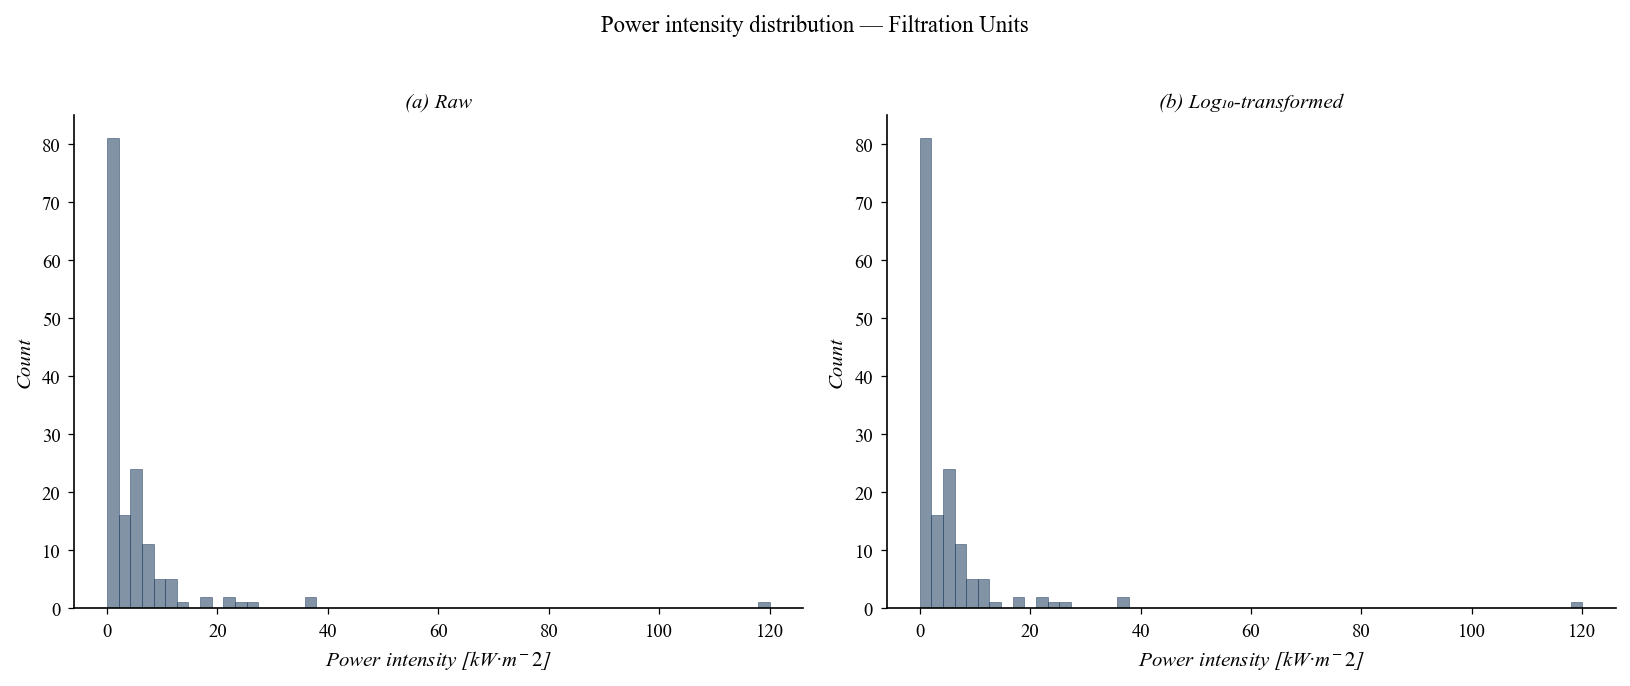

In [6]:
print("generating Figure S1c:\n")
bins = freedman_diaconis_bins(filters_raw["PowerToCapacity_kW·m⁻²"])
plot_pv_histogram(filters_raw, "PowerToCapacity_kW·m⁻²", "Filtration Units", "[kW·m⁻²]" , bins)

generating Figure S1c:



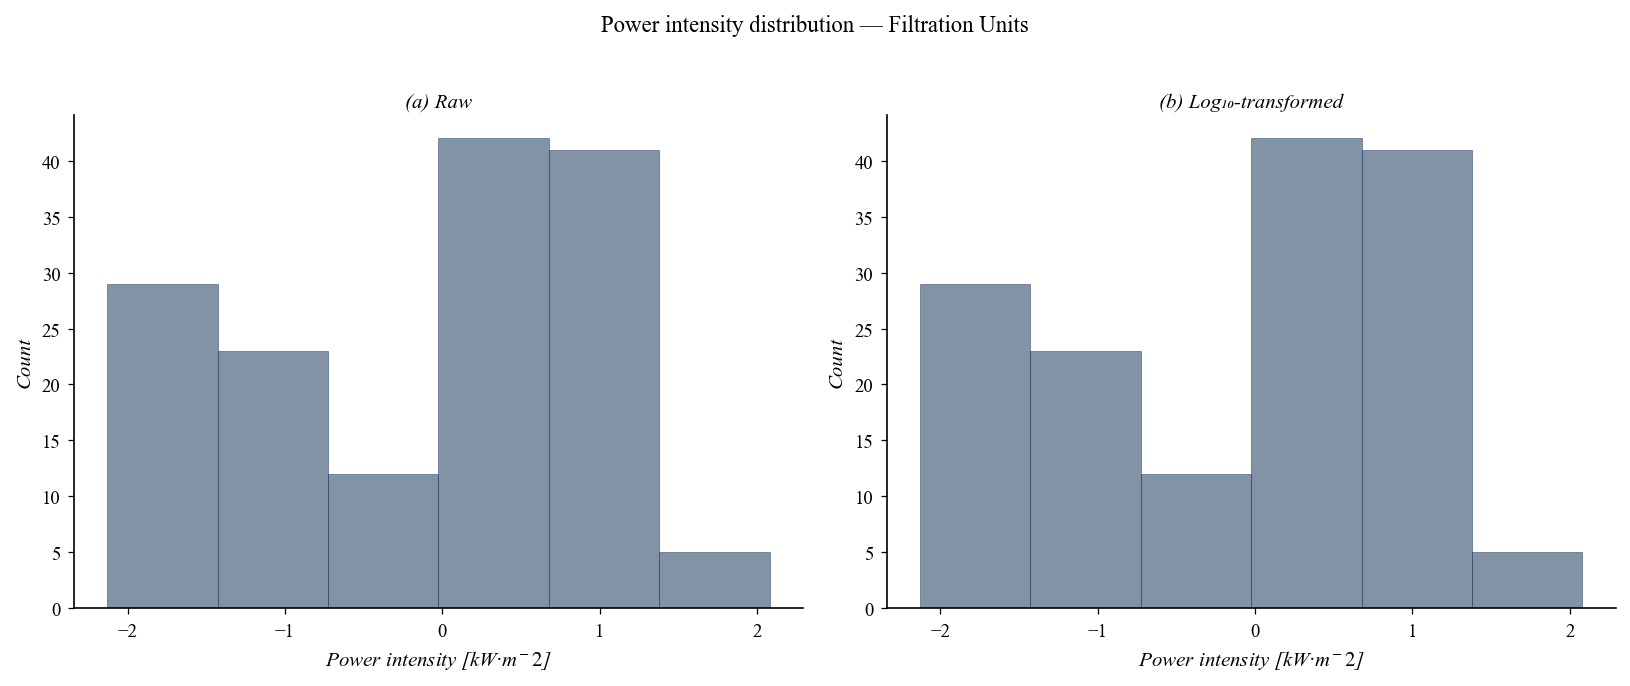

In [7]:
print("generating Figure S1c:\n")
bins = freedman_diaconis_bins(filters_raw["log(PowerToCapacity)"])
plot_pv_histogram(filters_raw, "log(PowerToCapacity)", "Filtration Units", "" , bins)

In [8]:
print("generating Table S1")
distributions_results_fu = distribution_kolmogorov_smirnov_tests(filters_raw["PowerToCapacity_kW·m⁻²"])
print(distributions_results_fu)

generating Table S1
  Distribution  KS Statistic        p-value
0   Log-normal        0.1578   9.012240e-04
1       Normal        0.3338   1.347023e-15
2   Triangular        0.7512   2.666221e-89
3      Uniform        0.8362  3.215199e-119


### ***3.1.2 Equipment Representation Across Sub-types***

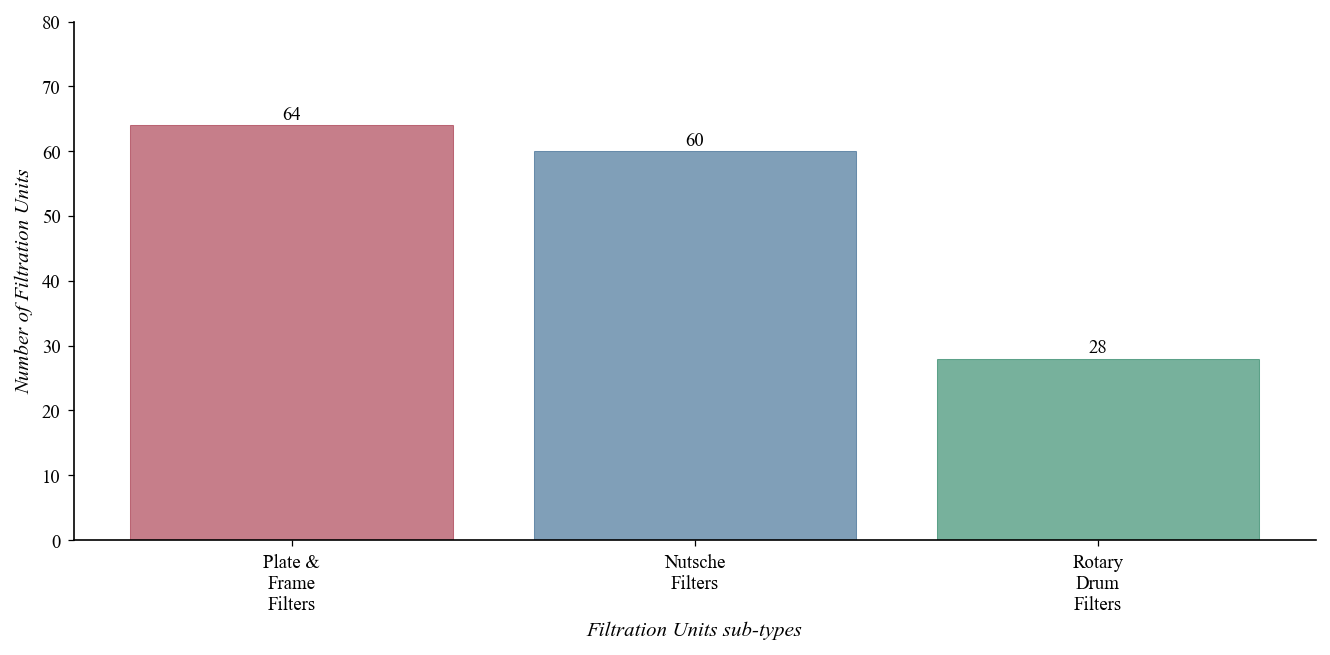

In [9]:
plot_equipment_type_distribution(df=filters_raw, equipment_type="Filtration Units")

### ***3.1.3 Power–Capacity Trends Across Filtration Unit Types***

generating Figure S2c:



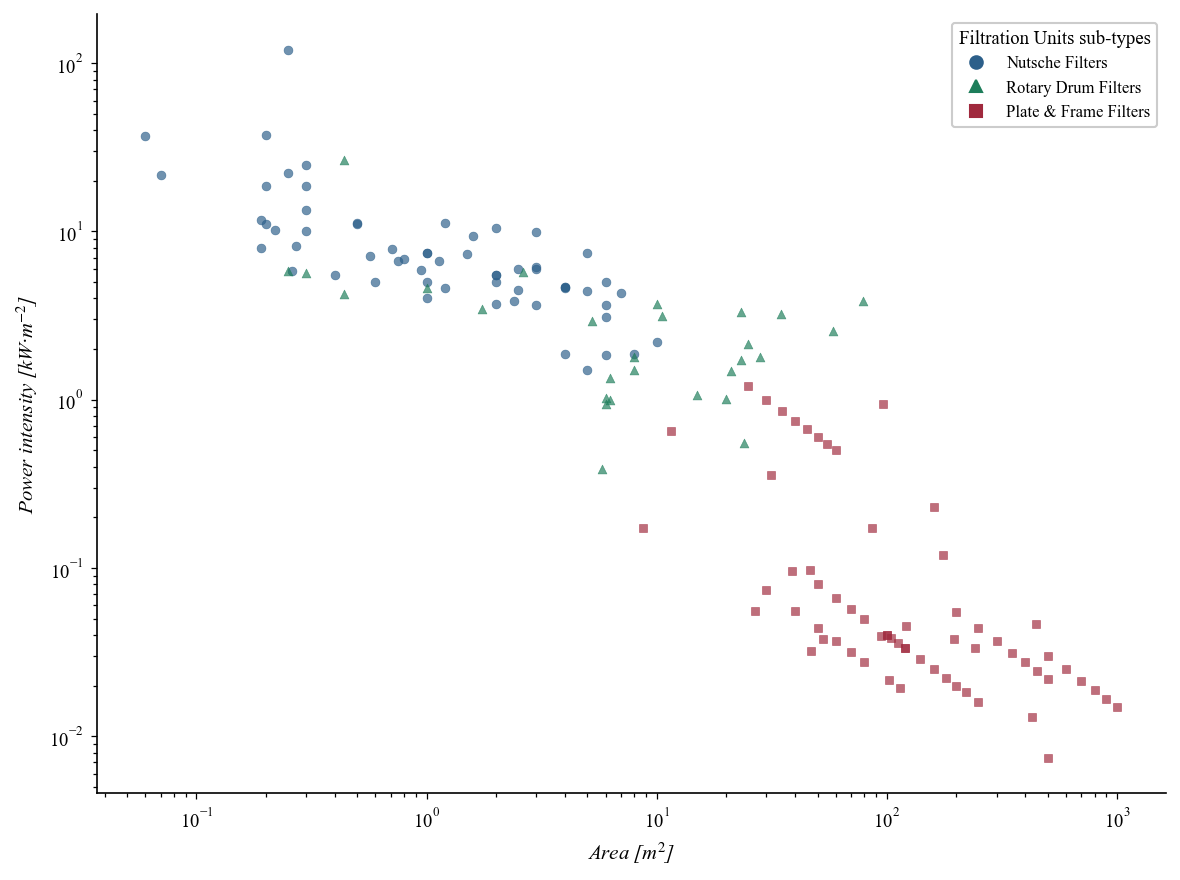

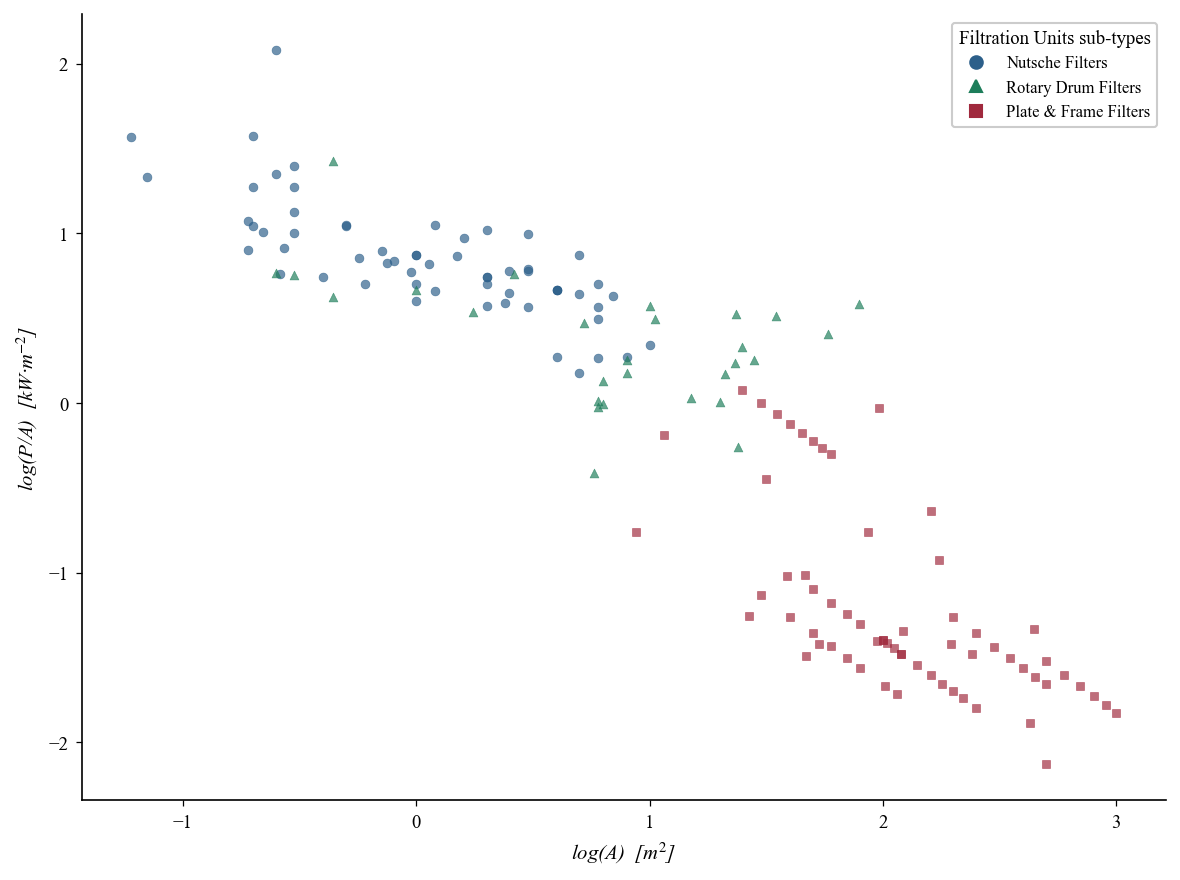

In [10]:
print("generating Figure S2c:\n")
type_color_map = {
    "Nutsche Filters":       "#2C5F8A",
    "Rotary Drum Filters":   "#1D7D5A",
    "Plate & Frame Filters": "#A0293D",
}

plot_pa_vs_a_by_type(df=filters_raw, type_color_map=type_color_map, equipment_type="Filtration Units")
plot_logpa_vs_loga_by_type(df=filters_raw, type_color_map=type_color_map, equipment_type="Filtration Units")


## ***3.2. Filtration Units: Model Selection***

### ***3.2.1 Models per Filtration Unit Type***

In [11]:
print("generating Table S2 and S3:\n")
model_selection_results_fu_combined = []
model_coeffs_fu_combined = []

for eq_type in filters_raw["Type"].unique():
    df_subset = filters_raw[filters_raw["Type"] == eq_type]
    
    model_selection_results, model_coeffs = polynomial_loglog_model_selection(df=df_subset, x_col="log(Capacity)", y_col="log(PowerToCapacity)", degrees=[1, 2, 3])
    model_selection_results["Type"] = eq_type
    model_coeffs["Type"] = eq_type
    
    model_selection_results_fu_combined.append(model_selection_results)
    model_coeffs_fu_combined.append(model_coeffs)

model_selection_results_fu_combined = pd.concat(model_selection_results_fu_combined, ignore_index=True)
model_coeffs_fu_combined = pd.concat(model_coeffs_fu_combined, ignore_index=True)

for eq_type in filters_raw["Type"].unique():
    print(f"\n{'='*60}")
    print(f"Model Selection Results for {eq_type}")
    print(f"{'='*60}")
    display(model_selection_results_fu_combined[model_selection_results_fu_combined["Type"] == eq_type])

    print(f"\nCoefficients for {eq_type}:")
    display(model_coeffs_fu_combined[model_coeffs_fu_combined["Type"] == eq_type])

generating Table S2 and S3:


Model Selection Results for Nutsche Filters


,Degree,R2,R2_adj,RMSE,AIC,BIC,F-stat,Significance_F,CI_zero,Eligible,Nested_F,Nested_F_p,Type
0,1,0.580482,0.573249,0.216915,-9.117452,-4.928763,80.253776,1.552928e-12,none,True,NaN,NaN,Nutsche Filters
1,2,0.581583,0.566902,0.216630,-7.275241,-0.992207,39.613937,1.643815e-11,a2,False,0.1501,0.6999,Nutsche Filters
2,3,0.584056,0.561774,0.215989,-5.630886,2.746493,26.211193,1.007439e-10,"a2, a3",False,0.3329,0.5663,Nutsche Filters



Coefficients for Nutsche Filters:


,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero,Type
0,1,Intercept,0.869630,30.434555,2.345792e-37,0.812433,0.926827,False,Nutsche Filters
1,1,x^1,-0.460668,-8.958447,1.552928e-12,-0.563601,-0.357734,False,Nutsche Filters
2,2,Intercept,0.858441,21.052277,1.459845e-28,0.776787,0.940095,False,Nutsche Filters
3,2,x^1,-0.458910,-8.824858,2.986940e-12,-0.563042,-0.354778,False,Nutsche Filters
4,2,x^2,0.035986,0.387423,6.998860e-01,-0.150015,0.221987,True,Nutsche Filters
5,3,Intercept,0.862900,20.673712,6.922884e-28,0.779286,0.946513,False,Nutsche Filters
6,3,x^1,-0.408823,-4.033830,1.678719e-04,-0.611849,-0.205797,False,Nutsche Filters
7,3,x^2,0.014002,0.138764,8.901345e-01,-0.188134,0.216138,True,Nutsche Filters
8,3,x^3,-0.081940,-0.576993,5.662565e-01,-0.366426,0.202545,True,Nutsche Filters



Model Selection Results for Rotary Drum Filters


...

,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero,Type
9,1,Intercept,0.584294,5.907680,0.000003,0.380994,0.787595,False,Rotary Drum Filters
10,1,x^1,-0.273400,-2.955190,0.006560,-0.463568,-0.083232,False,Rotary Drum Filters
11,2,Intercept,0.531300,5.966111,0.000003,0.347892,0.714708,False,Rotary Drum Filters
12,2,x^1,-0.666851,-4.223805,0.000278,-0.992009,-0.341692,False,Rotary Drum Filters
13,2,x^2,0.332289,2.910301,0.007482,0.097137,0.567440,False,Rotary Drum Filters
14,3,Intercept,0.696381,5.222168,0.000024,0.421158,0.971604,False,Rotary Drum Filters
15,3,x^1,-0.579328,-3.572209,0.001540,-0.914044,-0.244613,False,Rotary Drum Filters
16,3,x^2,-0.263622,-0.687670,0.498253,-1.054829,0.527585,True,Rotary Drum Filters
17,3,x^3,0.298369,1.623514,0.117543,-0.080934,0.677671,True,Rotary Drum Filters



Model Selection Results for Plate & Frame Filters


,Degree,R2,R2_adj,RMSE,AIC,BIC,F-stat,Significance_F,CI_zero,Eligible,Nested_F,Nested_F_p,Type
6,1,0.444420,0.435459,0.410169,71.552231,75.869997,49.595065,1.816051e-09,a0,False,NaN,NaN,Plate & Frame Filters
7,2,0.452348,0.434392,0.407232,72.632350,79.108999,25.192320,1.057762e-08,"a0, a1, a2",False,0.8831,0.3511,Plate & Frame Filters
8,3,0.467866,0.441260,0.401421,72.792676,81.428209,17.584538,2.629246e-08,"a0, a1, a2, a3",False,1.7497,0.1909,Plate & Frame Filters



Coefficients for Plate & Frame Filters:


,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero,Type
18,1,Intercept,0.423030,1.777487,8.039261e-02,-0.052712,0.898771,True,Plate & Frame Filters
19,1,x^1,-0.793692,-7.042376,1.816051e-09,-1.018981,-0.568403,False,Plate & Frame Filters
20,2,Intercept,1.194324,1.397470,1.673344e-01,-0.514620,2.903267,True,Plate & Frame Filters
21,2,x^1,-1.575087,-1.877052,6.529532e-02,-3.253028,0.102853,True,Plate & Frame Filters
22,2,x^2,0.188095,0.939730,3.510626e-01,-0.212147,0.588337,True,Plate & Frame Filters
23,3,Intercept,-1.823431,-0.749029,4.567662e-01,-6.692942,3.046080,True,Plate & Frame Filters
24,3,x^1,3.436613,0.885839,3.792409e-01,-4.323543,11.196769,True,Plate & Frame Filters
25,3,x^2,-2.444190,-1.222157,2.264278e-01,-6.444583,1.556202,True,Plate & Frame Filters
26,3,x^3,0.439593,1.322770,1.909313e-01,-0.225161,1.104347,True,Plate & Frame Filters


In [12]:
degrees_by_type = {
    "Nutsche Filters": 1,
    "Rotary Drum Filters": 1,
    "Plate & Frame Filters": 1,
}

## ***3.3. Filtration Units: Handling of Influential Points***

### ***3.3.1 Evaluating Leverages, Externally Studentized Residuals, Difference in Fits, and Cook's Distance***

generating Figure S10 - S12 and Table S5a:



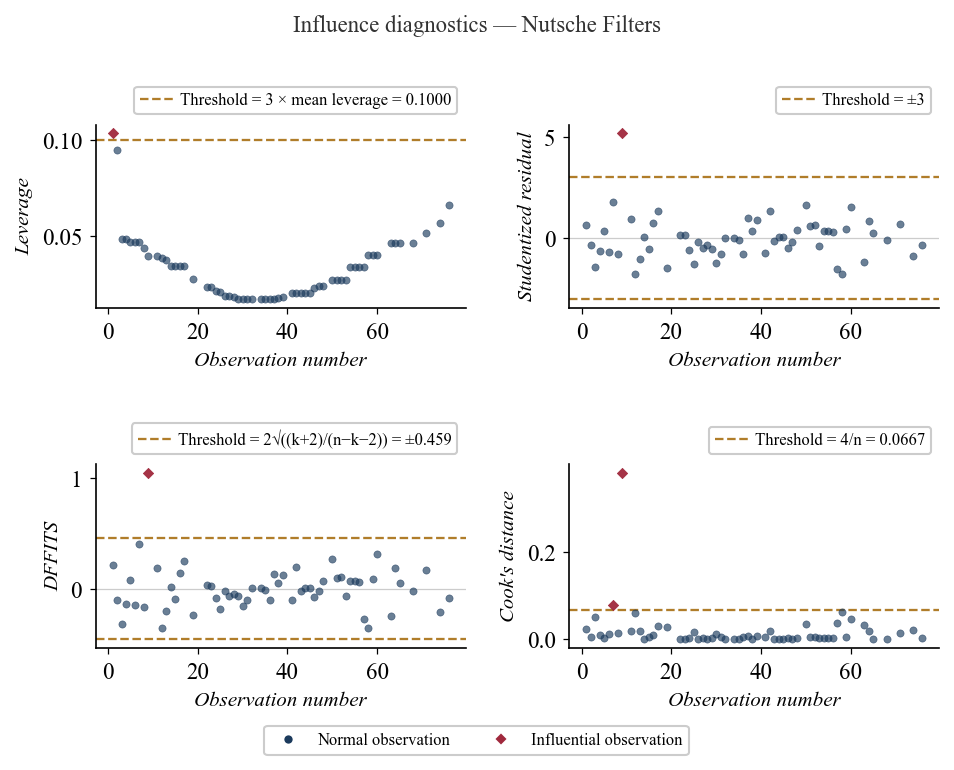


Influential points for Nutsche Filters:


,Capacity Sorted No.,Entry_No.,Area_m²,PowerToCapacity_kW·m⁻²,log(Capacity),log(PowerToCapacity),y_pred,Leverage,High_Leverage,StudResid,High_StudResid,DFFITS,High_DFFITS,CooksD,High_Cooks,Type
6,7,116,0.20,37.508710,-0.69897,1.574132,1.191623,0.046689,False,1.810238,False,0.400614,False,0.077215,True,Nutsche Filters
8,9,67,0.25,120.027872,-0.60206,2.079282,1.146980,0.039372,False,5.185102,True,1.049717,True,0.380940,True,Nutsche Filters


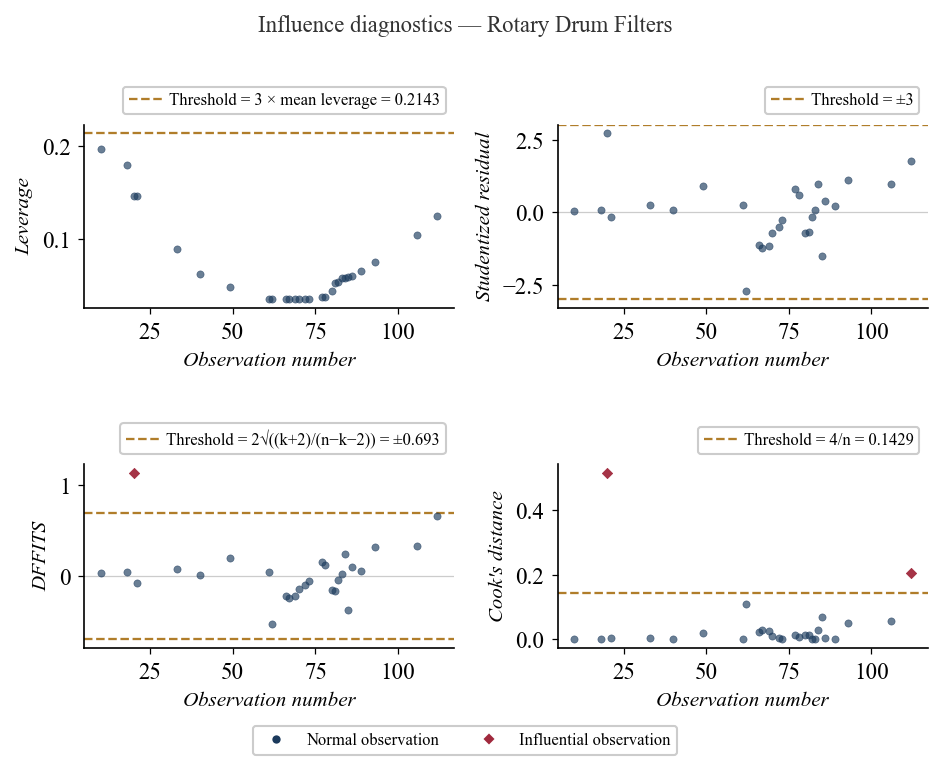


Influential points for Rotary Drum Filters:


,Capacity Sorted No.,Entry_No.,Area_m²,PowerToCapacity_kW·m⁻²,log(Capacity),log(PowerToCapacity),y_pred,Leverage,High_Leverage,StudResid,High_StudResid,DFFITS,High_DFFITS,CooksD,High_Cooks,Type
2,20,141,0.44,26.709618,-0.356547,1.426668,0.681775,0.146788,False,2.735343,False,1.134561,True,0.515175,True,Rotary Drum Filters
27,112,152,78.79,3.856743,1.896471,0.586221,0.065799,0.125274,False,1.754844,False,0.664099,False,0.204183,True,Rotary Drum Filters


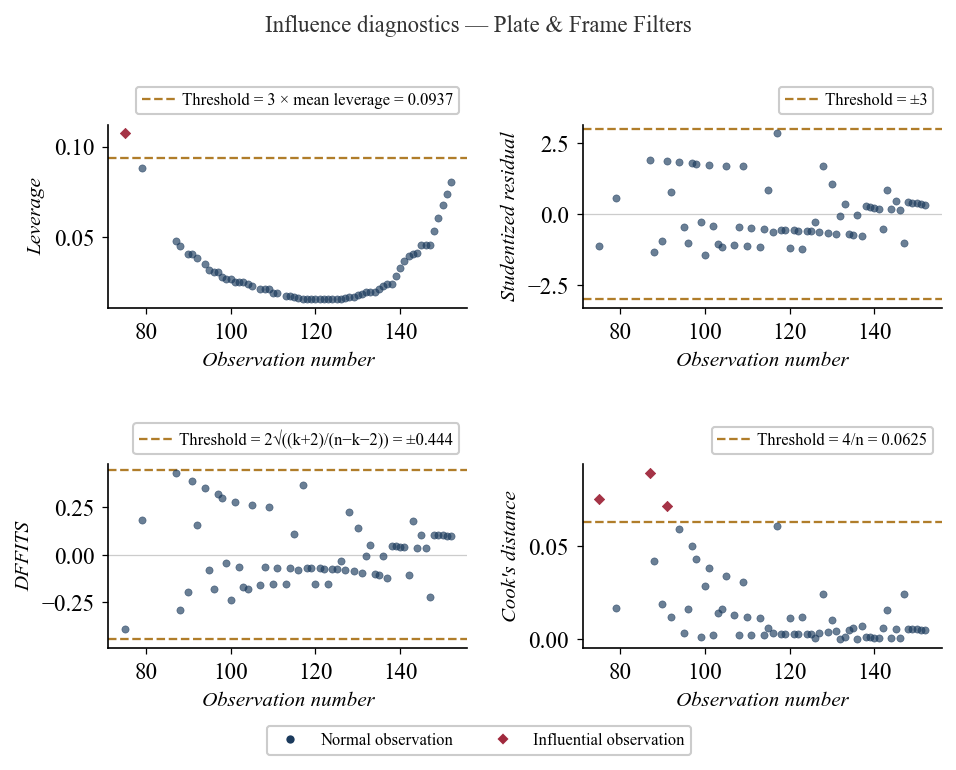


Influential points for Plate & Frame Filters:


,Capacity Sorted No.,Entry_No.,Area_m²,PowerToCapacity_kW·m⁻²,log(Capacity),log(PowerToCapacity),y_pred,Leverage,High_Leverage,StudResid,High_StudResid,DFFITS,High_DFFITS,CooksD,High_Cooks,Type
0,75,104,8.7,0.173140,0.939519,-0.761604,-0.322659,0.107531,True,-1.117181,False,-0.387787,False,0.074890,True,Plate & Frame Filters
2,87,3,25.0,1.200279,1.397940,0.079282,-0.686504,0.047732,False,1.923663,False,0.430677,False,0.088871,True,Plate & Frame Filters
5,91,2,30.0,1.000232,1.477121,0.000101,-0.749349,0.040516,False,1.872731,False,0.384831,False,0.071170,True,Plate & Frame Filters



Combined influential points across all types:


,Capacity Sorted No.,Entry_No.,Area_m²,PowerToCapacity_kW·m⁻²,log(Capacity),log(PowerToCapacity),y_pred,Leverage,High_Leverage,StudResid,High_StudResid,DFFITS,High_DFFITS,CooksD,High_Cooks,Type
0,7,116,0.20,37.508710,-0.698970,1.574132,1.191623,0.046689,False,1.810238,False,0.400614,False,0.077215,True,Nutsche Filters
1,9,67,0.25,120.027872,-0.602060,2.079282,1.146980,0.039372,False,5.185102,True,1.049717,True,0.380940,True,Nutsche Filters
2,20,141,0.44,26.709618,-0.356547,1.426668,0.681775,0.146788,False,2.735343,False,1.134561,True,0.515175,True,Rotary Drum Filters
3,112,152,78.79,3.856743,1.896471,0.586221,0.065799,0.125274,False,1.754844,False,0.664099,False,0.204183,True,Rotary Drum Filters
4,75,104,8.70,0.173140,0.939519,-0.761604,-0.322659,0.107531,True,-1.117181,False,-0.387787,False,0.074890,True,Plate & Frame Filters
5,87,3,25.00,1.200279,1.397940,0.079282,-0.686504,0.047732,False,1.923663,False,0.430677,False,0.088871,True,Plate & Frame Filters
6,91,2,30.00,1.000232,1.477121,0.000101,-0.749349,0.040516,False,1.872731,False,0.384831,False,0.071170,True,Plate & Frame Filters


In [13]:
print("generating Figure S10 - S12 and Table S5a:\n")
all_influential = [] 

for eq_type in filters_raw["Type"].unique():
    # Subset for this type
    df_subset = filters_raw[filters_raw["Type"] == eq_type]

    # Run influence measures
    df_influence, lev_thresh, resid_stud_thresh, dffits_thresh, cooks_d_thresh = influence_measures(df=df_subset, x_col="log(Capacity)", y_col="log(PowerToCapacity)", xcol="Area_m²", ycol="PowerToCapacity_kW·m⁻²", sorted_id_col="Capacity Sorted No.",  orig_id_col="Entry_No.", degrees_by_type=degrees_by_type)

    # Plot diagnostics
    plot_leverage(df_influence, equipment_type=eq_type, id_col="Capacity Sorted No.", mean_lev=None)
    
    # Identify influential points
    influential_points = df_influence[(df_influence["High_StudResid"]) |(df_influence["High_DFFITS"]) |(df_influence["High_Cooks"])].copy()

    # Add Type column
    influential_points["Type"] = eq_type

    # Append to master list
    all_influential.append(influential_points)

    # Show per-type results
    print(f"\nInfluential points for {eq_type}:")
    display(influential_points)

# Combine into one DataFrame
influential_by_fu_type_df = pd.concat(all_influential, ignore_index=True)

# Show the combined results
print("\nCombined influential points across all types:")
influential_by_fu_type_df


## ***3.4. Filtration Units: Regression (w/o and w/ Removed Outliers)***

### ***3.4.1 Filtration Unit Types, Before Outlier Removal***

generating Figure S26 - S28 part a:


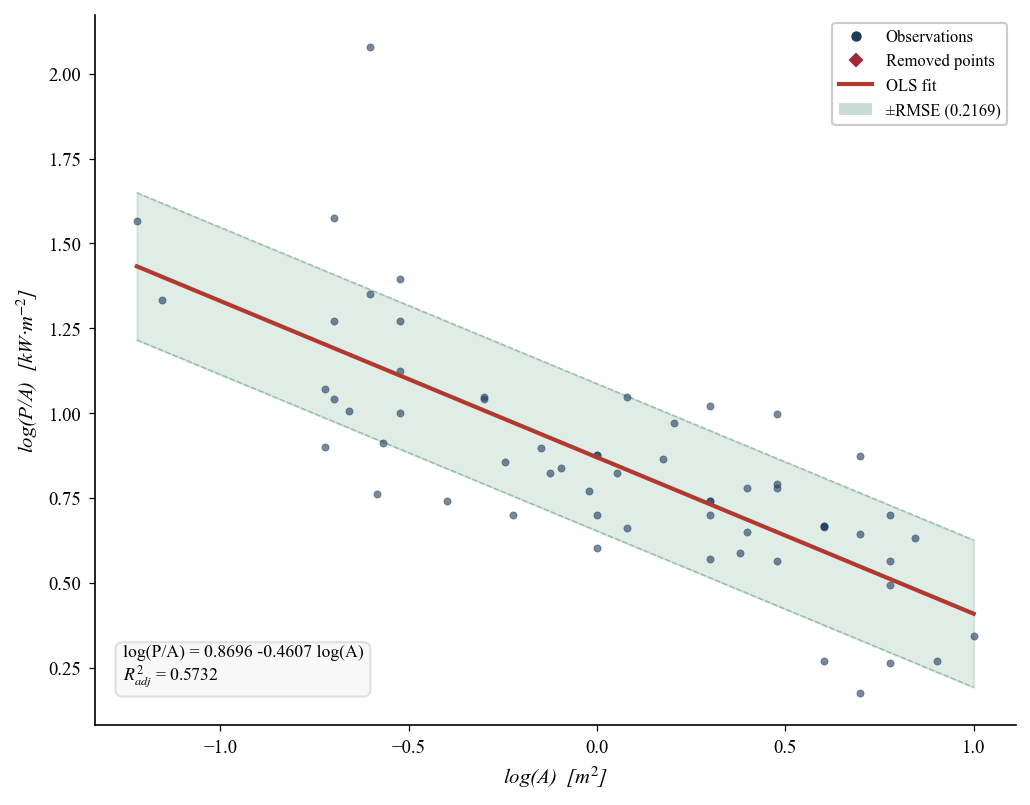

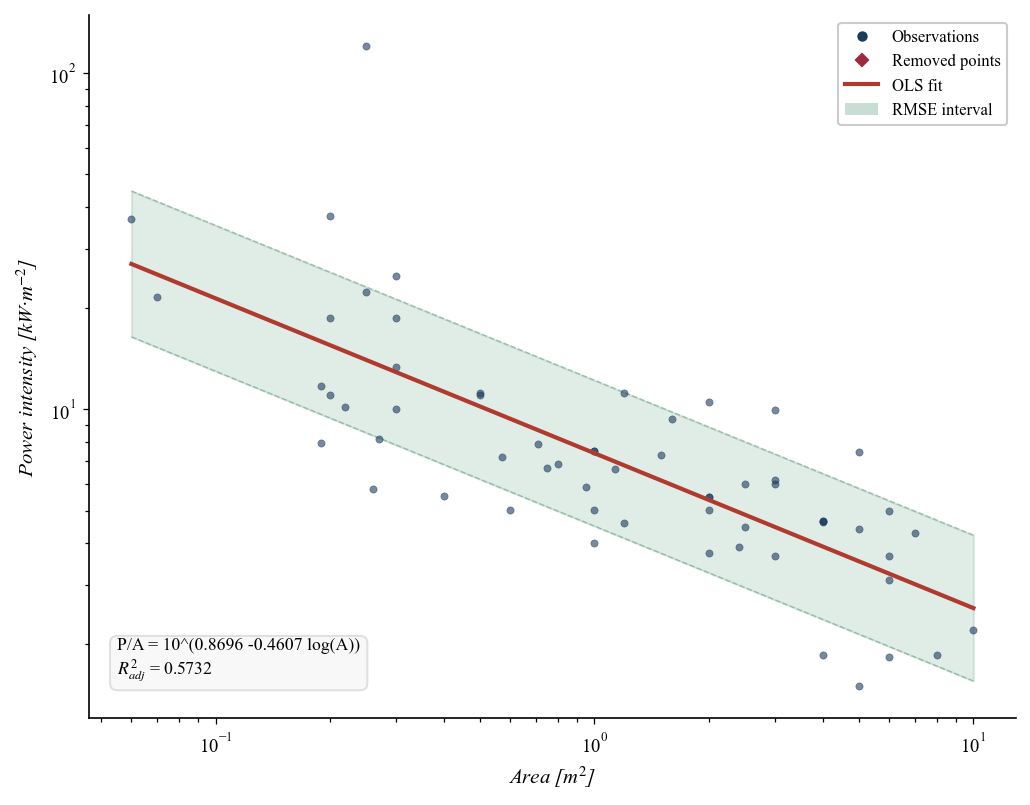

Finished plots for Nutsche Filters


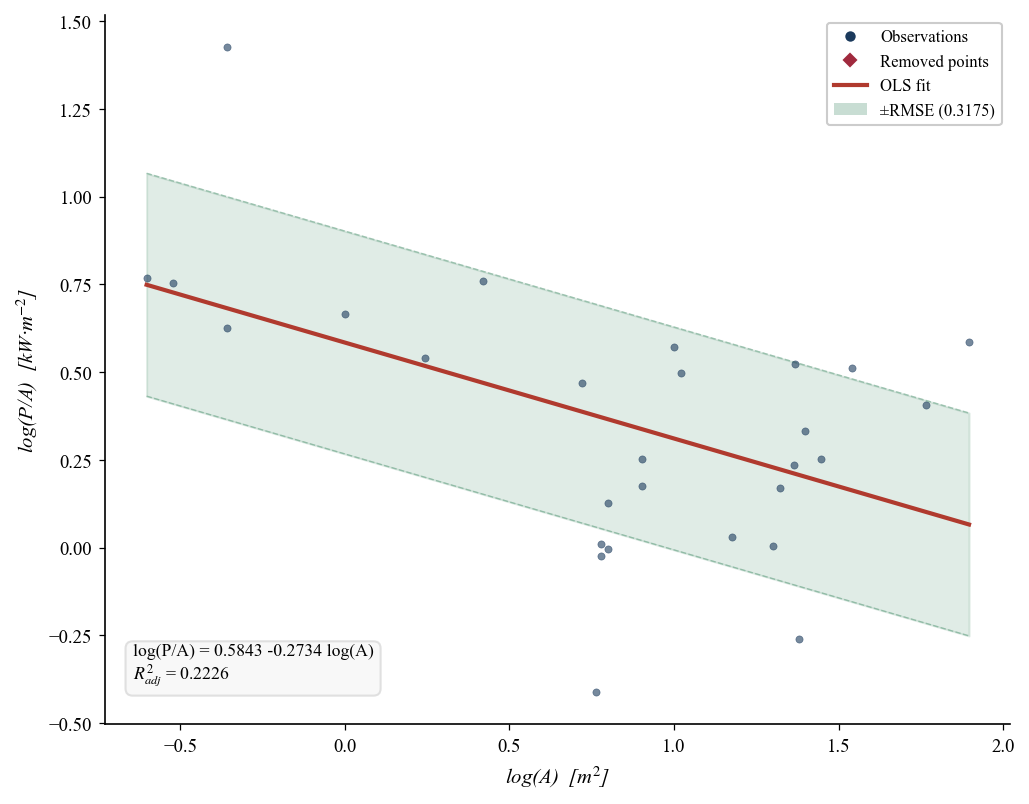

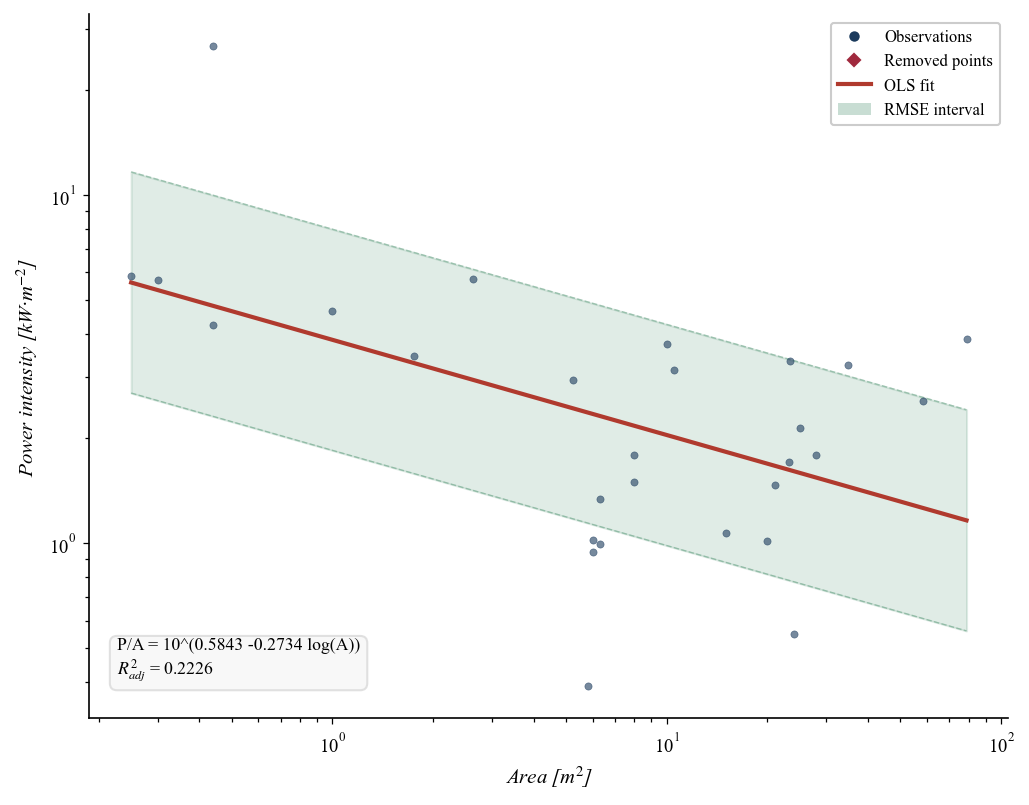

Finished plots for Rotary Drum Filters


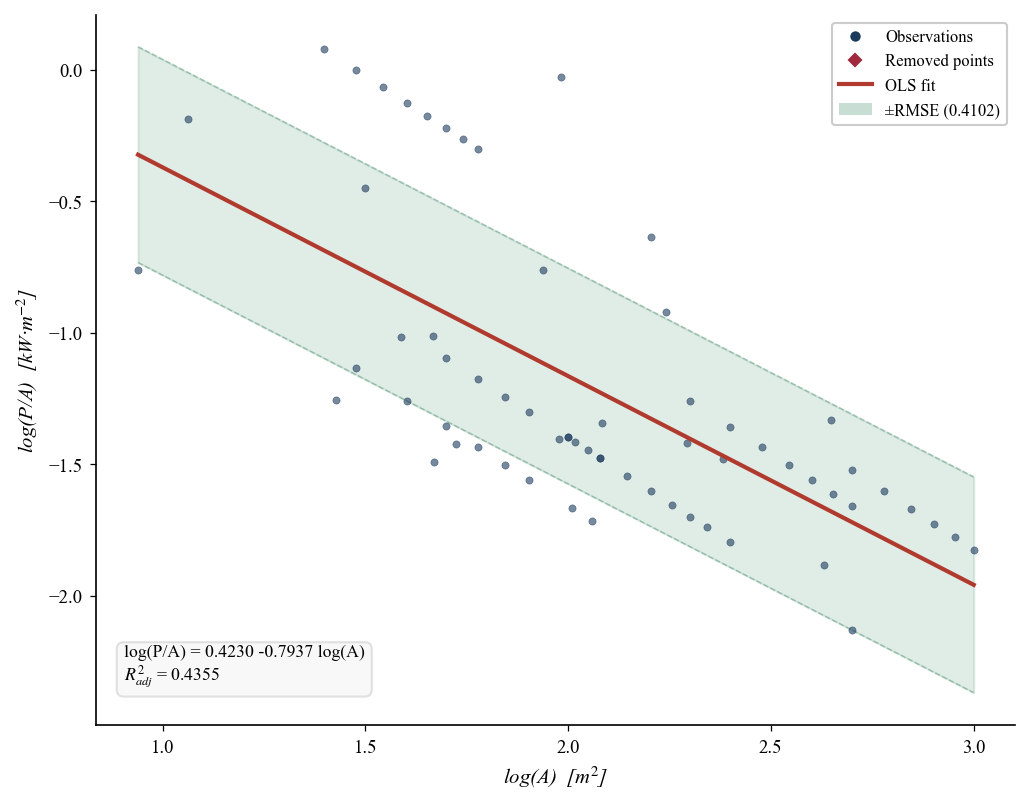

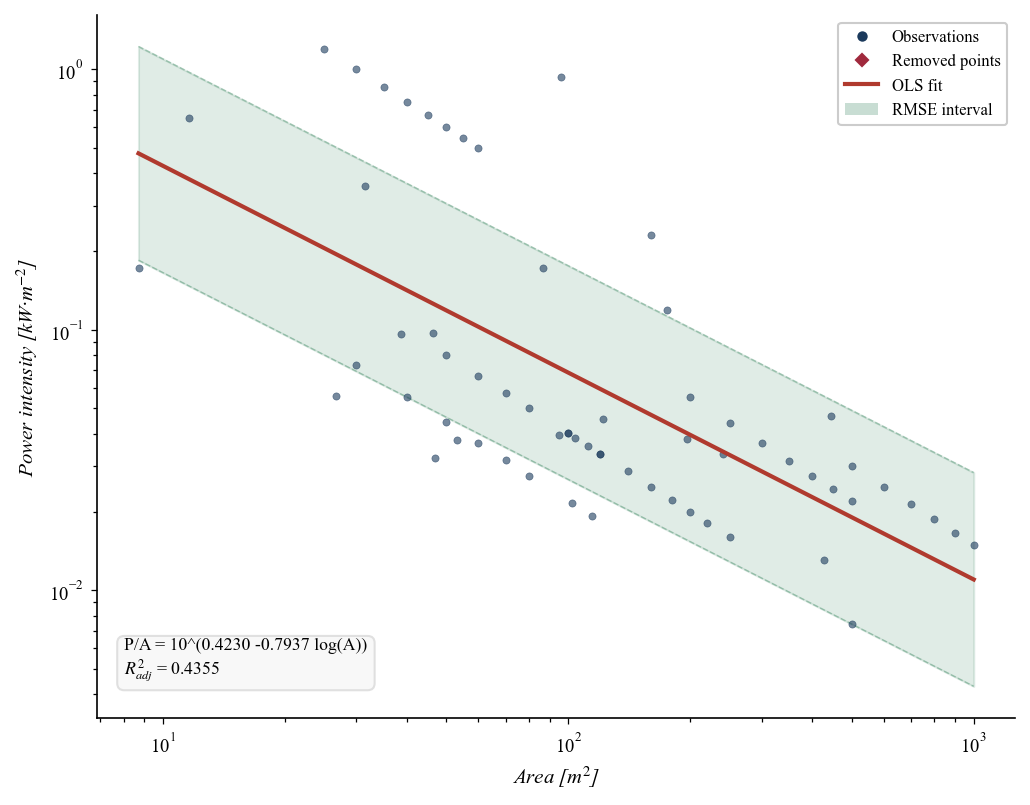

Finished plots for Plate & Frame Filters


In [14]:
print("generating Figure S26 - S28 part a:")
for eq_type in filters_raw["Type"].unique():

    df_subset = filters_raw[filters_raw["Type"] == eq_type]
    degree_value = degrees_by_type.get(eq_type, 1)
    degrees_list = [degree_value]

    # Model selection for this equipment type
    selected_model, selected_model_coeffs = polynomial_loglog_model_selection(df=df_subset, x_col="log(Capacity)", y_col="log(PowerToCapacity)", degrees=degrees_list)

    # Plot in log-log space
    plot_fit_unified(df=df_subset, x_col="log(Capacity)", y_col="log(PowerToCapacity)", df_coefs=selected_model_coeffs, df_model=selected_model, equipment_type = eq_type, loglog=True, df_influential=None)

    # Plot in normal space
    plot_fit_unified(df=df_subset, x_col="Area_m²", y_col="PowerToCapacity_kW·m⁻²", df_coefs=selected_model_coeffs, df_model=selected_model, equipment_type = eq_type, loglog=False, df_influential=None)

    print(f"Finished plots for {eq_type}")


### ***3.4.2 Filtration Units Types All Together, Before Outlier Removal***

In [15]:
print("generating Table Sx")
selected_model_fu, selected_model_coeffs_fu = polynomial_loglog_model_selection(df = filters_raw, x_col = "log(Capacity)", y_col = "log(PowerToCapacity)", degrees = [1])
selected_model_fu

generating Table Sx


,Degree,R2,R2_adj,RMSE,AIC,BIC,F-stat,Significance_F,CI_zero,Eligible,Nested_F,Nested_F_p
0,1,0.824338,0.823167,0.441894,187.085278,193.133039,703.911444,1.604697e-58,none,True,NaN,NaN


In [16]:
print("generating Table Sx")
selected_model_coeffs_fu

generating Table Sx


,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero
0,1,Intercept,0.82440,16.355228,3.684415e-35,0.724802,0.923997,False
1,1,x^1,-0.89959,-26.531329,1.604697e-58,-0.966586,-0.832593,False


generating Figure Sx


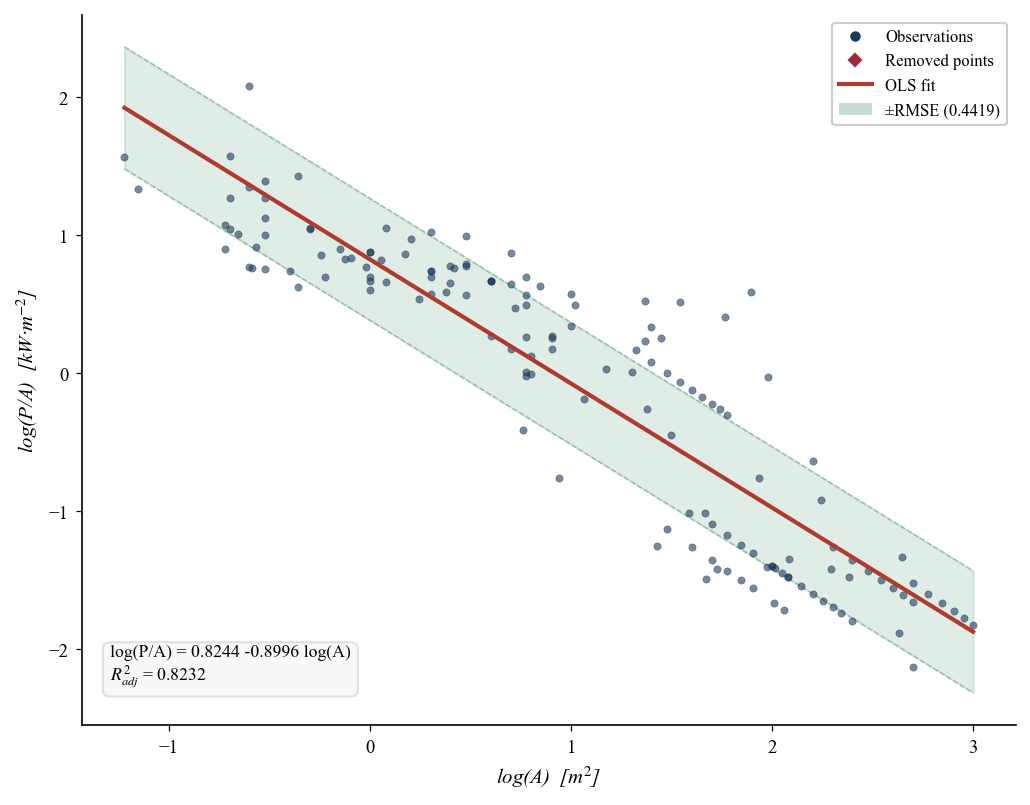

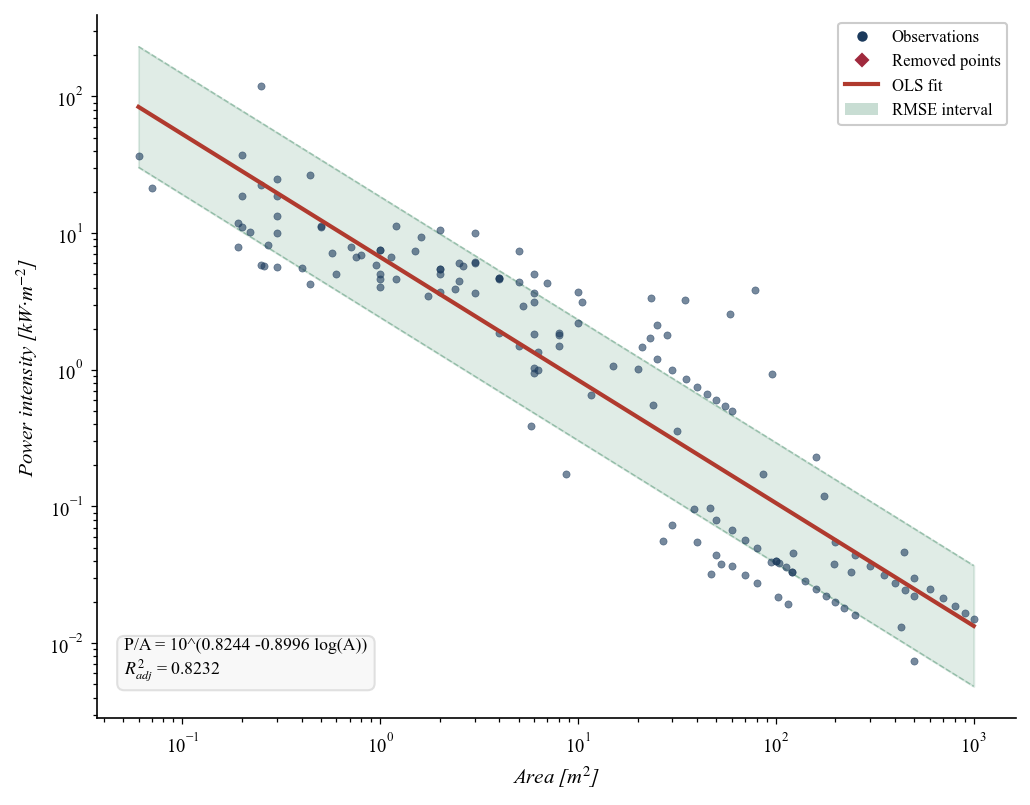

In [17]:
print("generating Figure Sx")
plot_fit_unified(df=filters_raw, x_col="log(Capacity)", y_col="log(PowerToCapacity)", equipment_type = "Filtration Units", df_coefs=selected_model_coeffs_fu, df_model=selected_model_fu, loglog=True, df_influential=None)
plot_fit_unified(df=filters_raw, x_col="Area_m²", y_col="PowerToCapacity_kW·m⁻²", equipment_type = "Filtration Units", df_coefs=selected_model_coeffs_fu, df_model=selected_model_fu, loglog=False, df_influential=None)

### ***3.4.3 Filtration Units Types, After Outlier Removal***

In [18]:
filters_clean = filters_raw[~filters_raw["Entry_No."].isin(influential_by_fu_type_df["Entry_No."])].reset_index(drop = True)
filters_clean.head()

,Capacity Sorted No.,Entry_No.,Type,Area_m²,Power_kW,PowerToCapacity_kW·m⁻²,log(Capacity),log(PowerToCapacity)
0,1,65,Nutsche Filters,0.06,2.207272,36.787867,-1.221849,1.565705
1,2,14,Nutsche Filters,0.07,1.506314,21.518771,-1.154902,1.332817
2,3,78,Nutsche Filters,0.19,1.506314,7.927968,-0.721246,0.899162
3,4,86,Nutsche Filters,0.19,2.237100,11.774211,-0.721246,1.070932
4,5,71,Nutsche Filters,0.20,3.728500,18.642500,-0.698970,1.270504


generating Figure S26 - S28 part b:


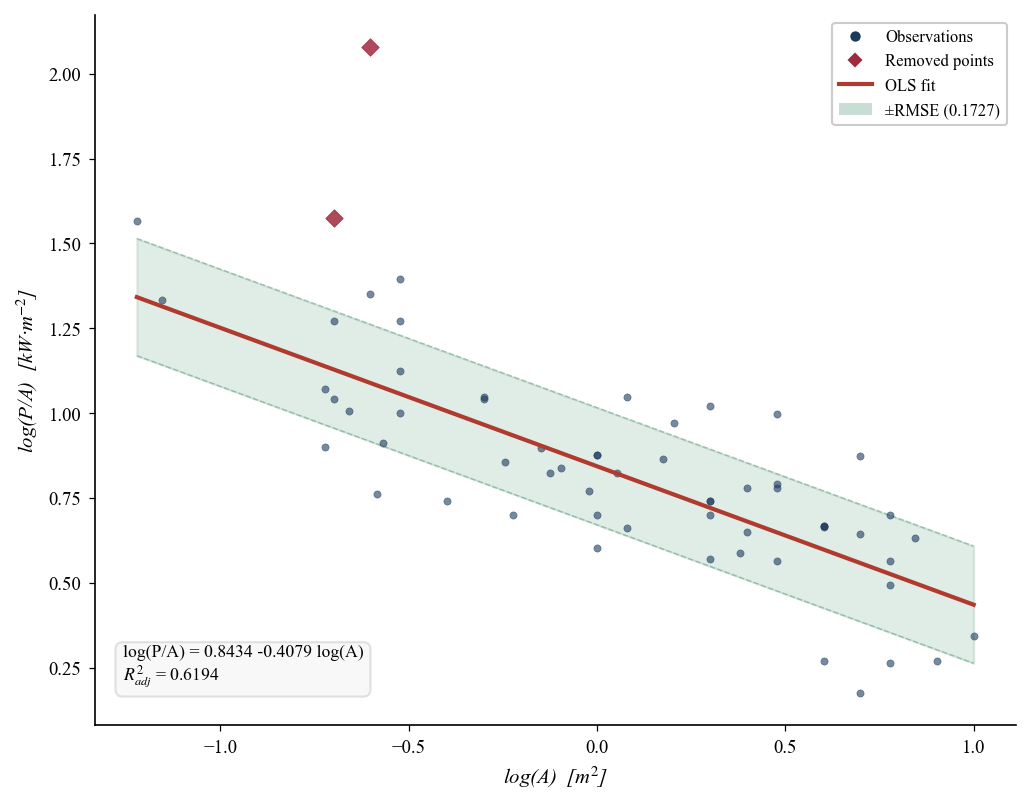

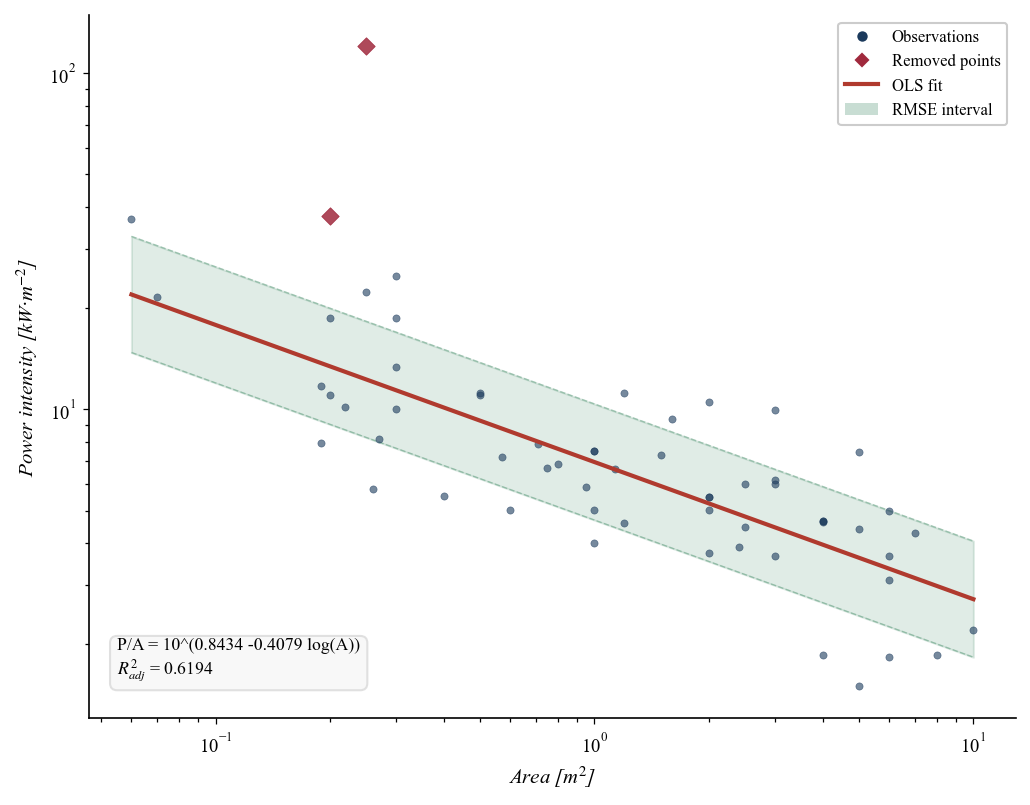

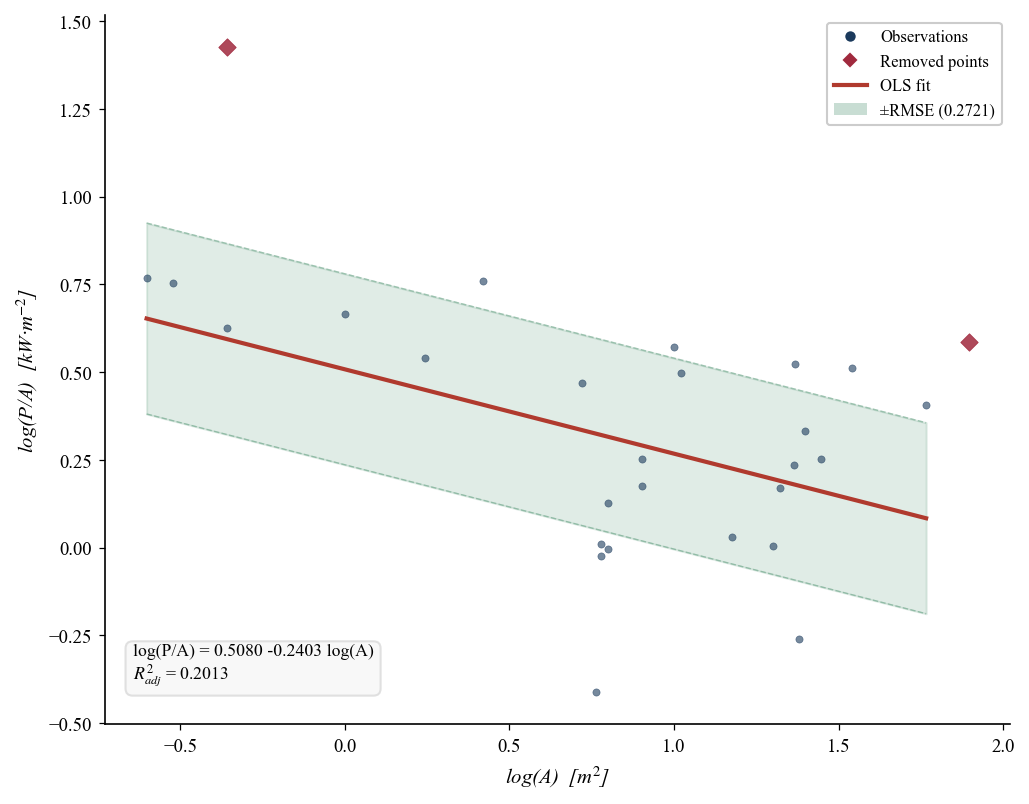

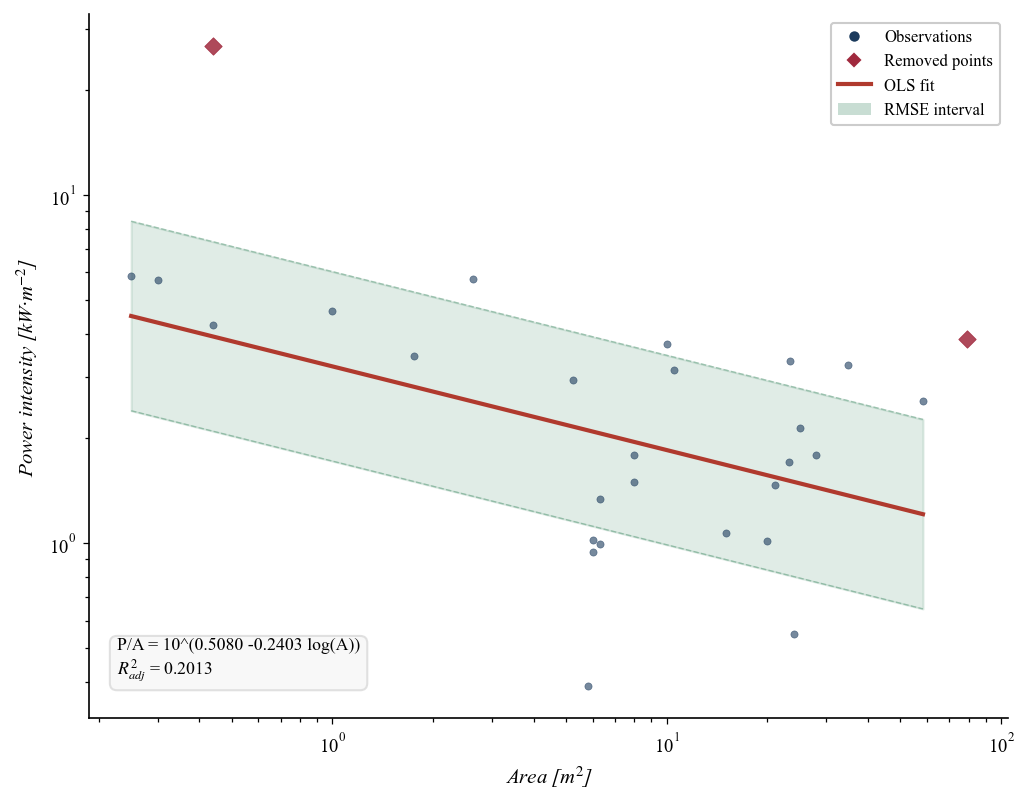

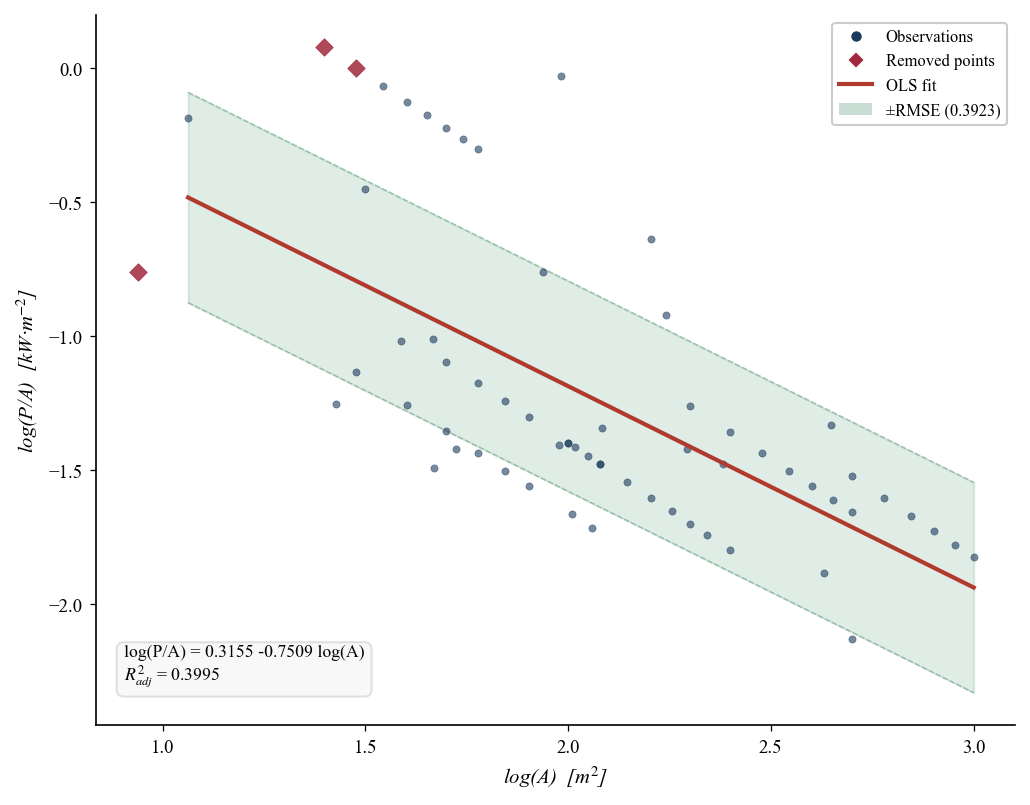

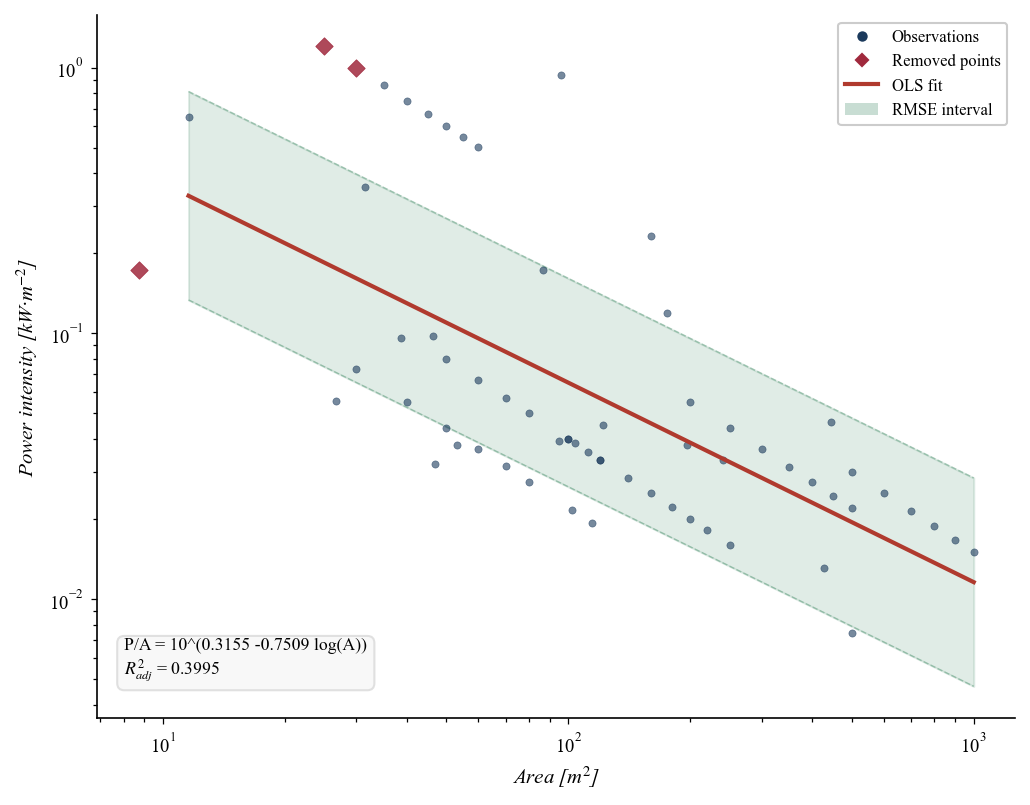

In [19]:
print("generating Figure S26 - S28 part b:")
all_coeffs_list_clean = []

for eq_type in filters_clean["Type"].unique():
    # --- Subset data for this equipment subtype ---
    df_subset = filters_clean[filters_clean["Type"] == eq_type]
    degree_value = degrees_by_type.get(eq_type, 1)
    degrees_list = [degree_value]

    # --- Model selection for this subtype ---
    selected_model, selected_model_coeffs = polynomial_loglog_model_selection(df=df_subset, x_col="log(Capacity)", y_col="log(PowerToCapacity)", degrees=degrees_list)

    selected_model_coeffs = selected_model_coeffs.copy()
    selected_model_coeffs["Type"] = eq_type
    all_coeffs_list_clean.append(selected_model_coeffs)


    # Prepare influential points for LOG–LOG plot
    temp_influential_log = (influential_by_fu_type_df.loc[influential_by_fu_type_df["Type"].eq(eq_type),["log(Capacity)", "log(PowerToCapacity)"]].dropna().reset_index(drop=True))

    # --- Plot in log–log space ---
    plot_fit_unified(df=df_subset, x_col="log(Capacity)", y_col="log(PowerToCapacity)", df_coefs=selected_model_coeffs, df_model=selected_model, equipment_type=eq_type, capacity_type="A", loglog=True, df_influential=temp_influential_log)


    # Prepare influential points for RAW plot
    temp_influential_raw = (influential_by_fu_type_df.loc[influential_by_fu_type_df["Type"].eq(eq_type),["Area_m²", "PowerToCapacity_kW·m⁻²"]].dropna().reset_index(drop=True))

    # --- Plot in raw (back-transformed) space ---
    plot_fit_unified(df=df_subset, x_col="Area_m²", y_col="PowerToCapacity_kW·m⁻²", df_coefs=selected_model_coeffs, df_model=selected_model, equipment_type=eq_type, capacity_type="A", loglog=False, df_influential=temp_influential_raw)

    all_coeffs_df_filters = pd.concat(all_coeffs_list_clean, ignore_index=True)

### ***3.4.4  Robust (HC3) Results for Filtration Unit Types, After Outlier Removal***

In [20]:
print("generating Table S12:\n")
for eq_type in filters_clean["Type"].unique():
    degree = int(degrees_by_type[eq_type][0]) if isinstance(degrees_by_type[eq_type], list) else degrees_by_type[eq_type]
    print(f"\n=== {eq_type} (Polynomial degree = {degree}) ===")

    df_subset = filters_clean[filters_clean["Type"] == eq_type]
    x = df_subset["log(Capacity)"].values
    y = df_subset["log(PowerToCapacity)"].values

    X_poly = np.vander(x, degree + 1, increasing=True)
    ols_model = sm.OLS(y, X_poly).fit()

    print(f"\n--- Standard OLS Results for {eq_type} ---")
    print(ols_model.summary())

    robust_model = ols_model.get_robustcov_results(cov_type="HC3")
    print(f"\n--- Robust (HC3) Results for {eq_type} ---")
    print(robust_model.summary())
    print("\n" + "=" * 90 + "\n")

generating Table S12:


=== Nutsche Filters (Polynomial degree = 1) ===

--- Standard OLS Results for Nutsche Filters ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     93.76
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.45e-13
Time:                        15:50:21   Log-Likelihood:                 19.570
No. Observations:                  58   AIC:                            -35.14
Df Residuals:                      56   BIC:                            -31.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------

### ***3.4.5 Assumptions Check for Filtration Units Types, After Outlier Removal***

generating Figure S41 and Table S22:



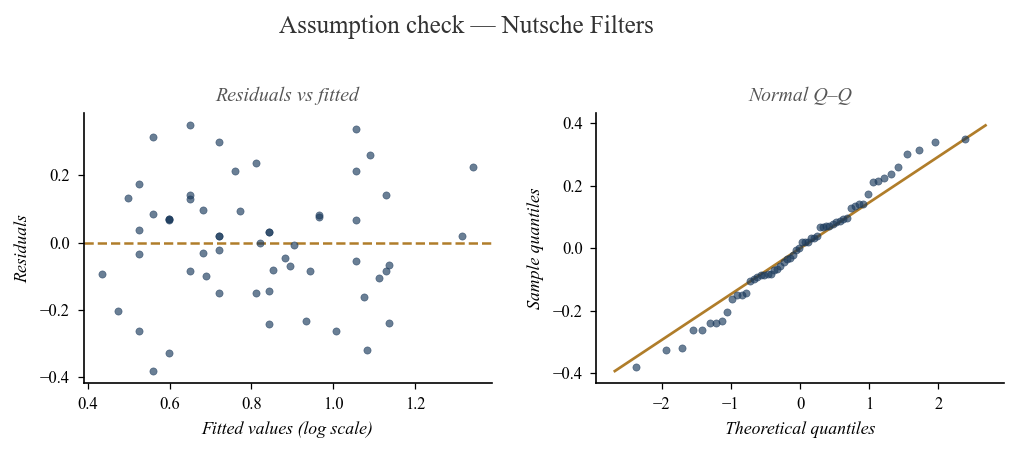

Kolmogorov–Smirnov Test (Normality):
  Statistic = 0.0505, p-value = 0.9968
  Residuals: not rejected.

Breusch-Pagan Test (Heteroscedasticity):
  LM-statistic = 0.0318, p-value = 0.8584
  Breusch-Pagan: not rejected.


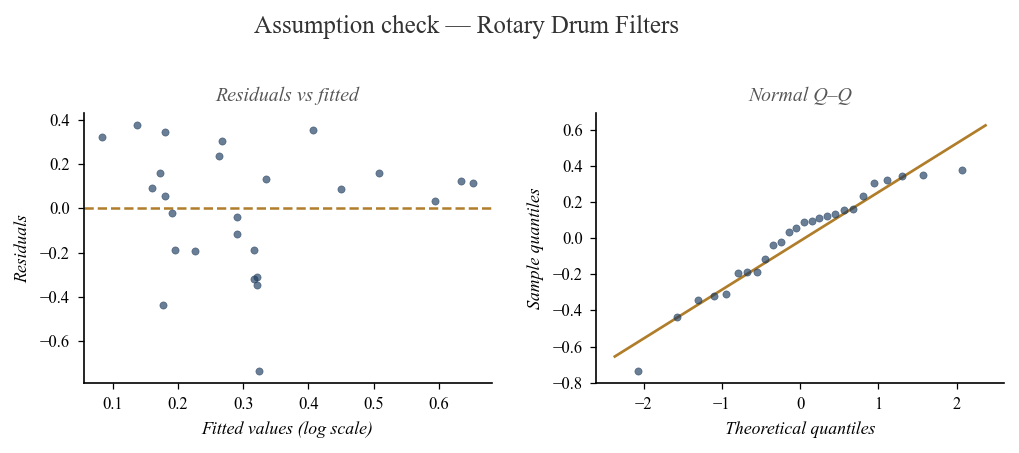

Shapiro–Wilk Test (Normality):
  Statistic = 0.9426, p-value = 0.1549
  Residuals: not rejected.

Breusch-Pagan Test (Heteroscedasticity):
  LM-statistic = 0.6109, p-value = 0.4345
  Breusch-Pagan: not rejected.


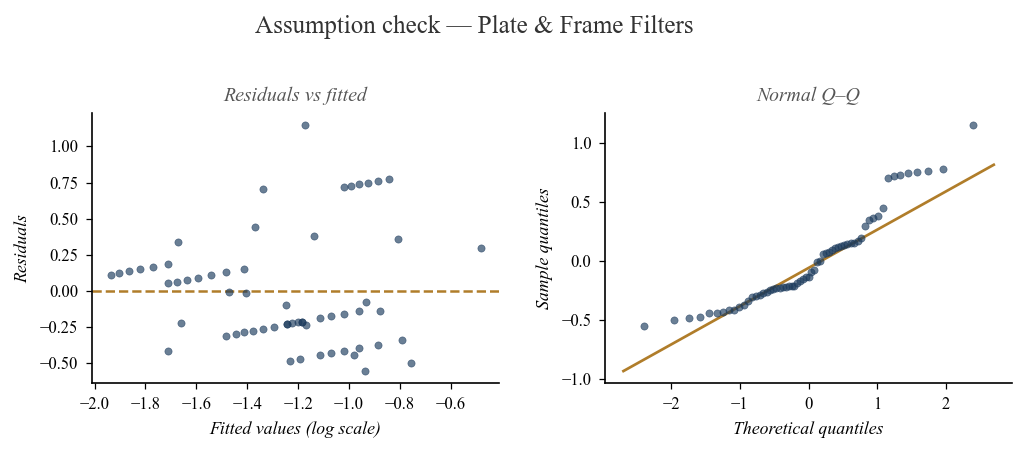

Kolmogorov–Smirnov Test (Normality):
  Statistic = 0.1429, p-value = 0.15
  Residuals: not rejected.

Breusch-Pagan Test (Heteroscedasticity):
  LM-statistic = 7.8183, p-value = 0.005172
  Breusch-Pagan: rejected.


In [21]:
print("generating Figure S41 and Table S22:\n")
for eq_type in filters_clean["Type"].unique():
    degree = degrees_by_type.get(eq_type, 1)
    df_subset = filters_clean[filters_clean["Type"] == eq_type]
    model_m = regression_diagnostics(x_log = df_subset["log(Capacity)"].values, y_log = df_subset["log(PowerToCapacity)"].values, equipment_type = eq_type, degree=degree)

### ***3.4.6 Filtration Units Types All Together, After Outlier Removal***

In [22]:
selected_model_fu, selected_model_coeffs_fu = polynomial_loglog_model_selection(df = filters_clean, x_col = "log(Capacity)", y_col = "log(PowerToCapacity)", degrees = [1])

selected_model_fu

,Degree,R2,R2_adj,RMSE,AIC,BIC,F-stat,Significance_F,CI_zero,Eligible,Nested_F,Nested_F_p
0,1,0.83649,0.835346,0.421831,165.178258,171.131725,731.563678,4.267150e-58,none,True,NaN,NaN


In [23]:
selected_model_coeffs_fu

,Degree,Term,Coefficient,t-stat,p-value,CI Lower,CI Upper,CI_zero
0,1,Intercept,0.804047,16.125322,5.523977e-34,0.705484,0.902610,False
1,1,x^1,-0.898995,-27.047434,4.267150e-58,-0.964696,-0.833294,False


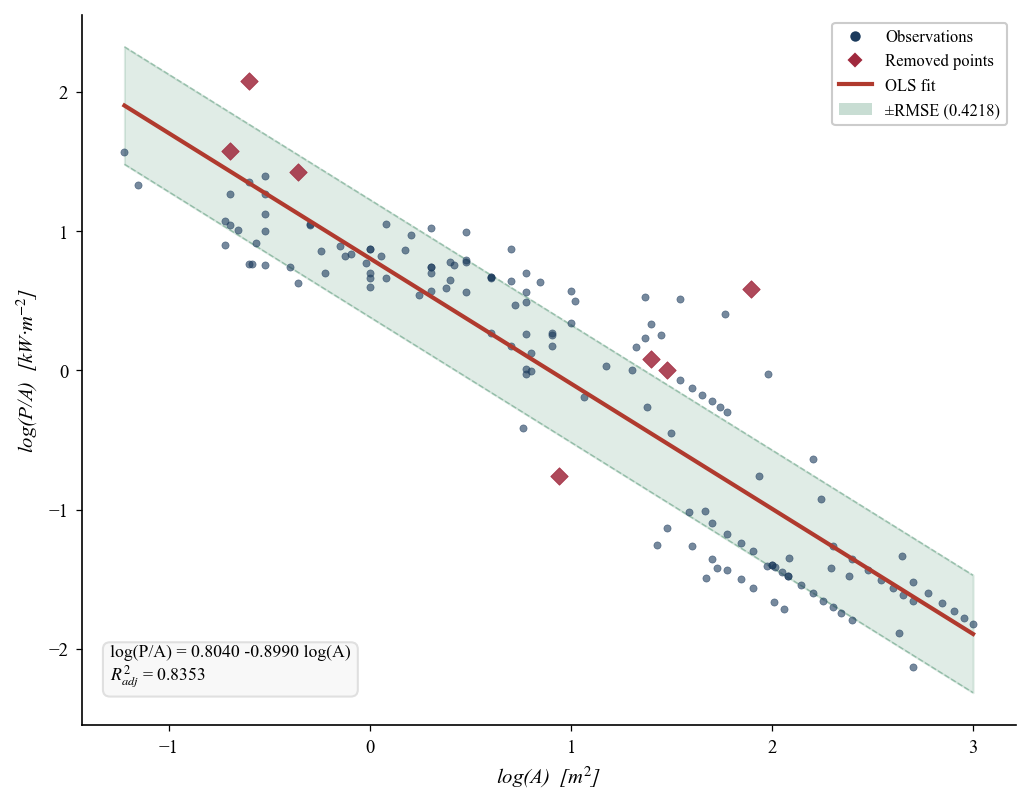

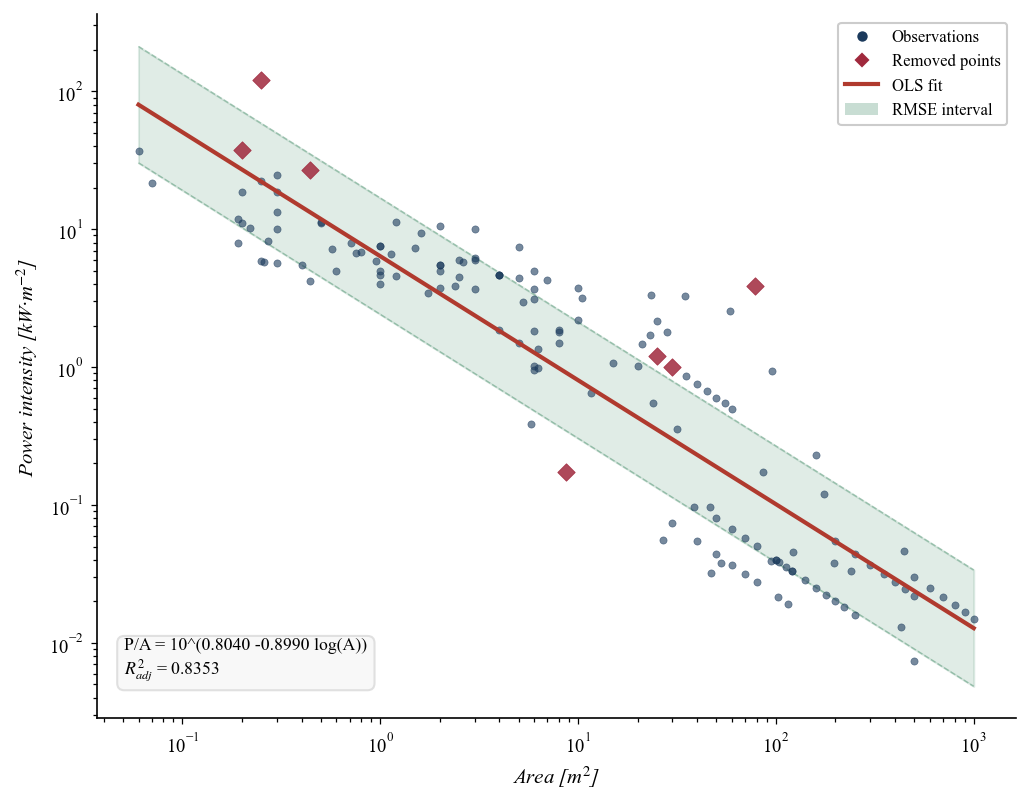

In [24]:
plot_fit_unified(df=filters_clean, x_col="log(Capacity)", y_col="log(PowerToCapacity)", df_coefs=selected_model_coeffs_fu, equipment_type="Filtration Units", df_model=selected_model_fu, loglog=True, df_influential=influential_by_fu_type_df)
plot_fit_unified(df=filters_clean, x_col="Area_m²", y_col="PowerToCapacity_kW·m⁻²", df_coefs=selected_model_coeffs_fu, equipment_type="Filtration Units", df_model=selected_model_fu, loglog=False, df_influential=influential_by_fu_type_df)

### ***3.4.7  Robust (HC3) Results for All Filtration Units, After Outlier Removal***

In [25]:
x = filters_clean["log(Capacity)"].values
y = filters_clean["log(PowerToCapacity)"].values

degree = 1   

X_poly = np.vander(x, degree + 1, increasing=True)  

# Fit OLS regression
ols_model = sm.OLS(y, X_poly).fit()

# Classic OLS summary
print(f"=== Standard OLS (Polynomial degree = {degree}) Results ===")
print(ols_model.summary())

# Robust (HC3) standard errors
robust_model = ols_model.get_robustcov_results(cov_type="HC3")
print(f"\n=== Robust (HC3) Results for degree = {degree} ===")
print(robust_model.summary())

=== Standard OLS (Polynomial degree = 1) Results ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     731.6
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           4.27e-58
Time:                        15:50:22   Log-Likelihood:                -80.589
No. Observations:                 145   AIC:                             165.2
Df Residuals:                     143   BIC:                             171.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

### ***3.4.8 Assumptions Check for All Filtration Units, After Outlier Removal***

generating Figure S41 and Table S22:



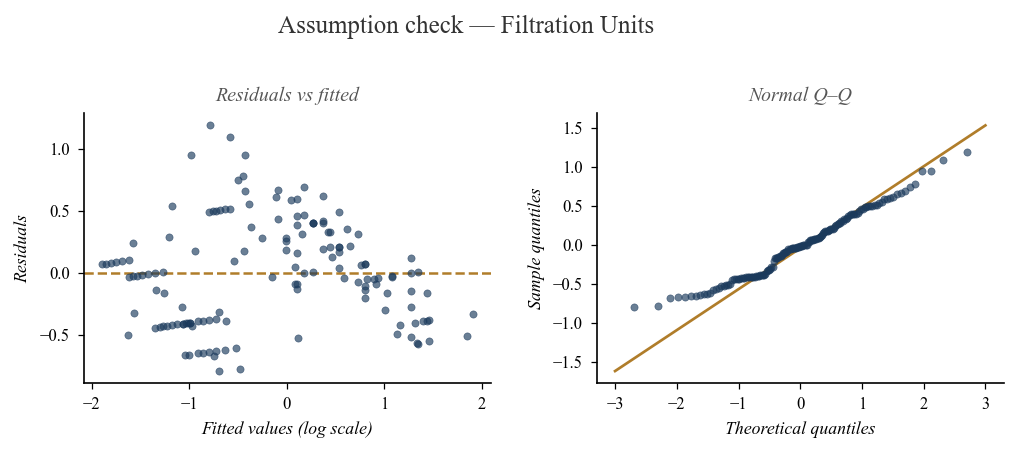

Kolmogorov–Smirnov Test (Normality):
  Statistic = 0.1006, p-value = 0.09903
  Residuals: not rejected.

Breusch-Pagan Test (Heteroscedasticity):
  LM-statistic = 3.1114, p-value = 0.07774
  Breusch-Pagan: not rejected.


In [26]:
print("generating Figure S41 and Table S22:\n")
model_fu = regression_diagnostics(x_log = filters_clean["log(Capacity)"].values, y_log = filters_clean["log(PowerToCapacity)"].values, equipment_type = "Filtration Units", degree=1)

generating Figure 2b:



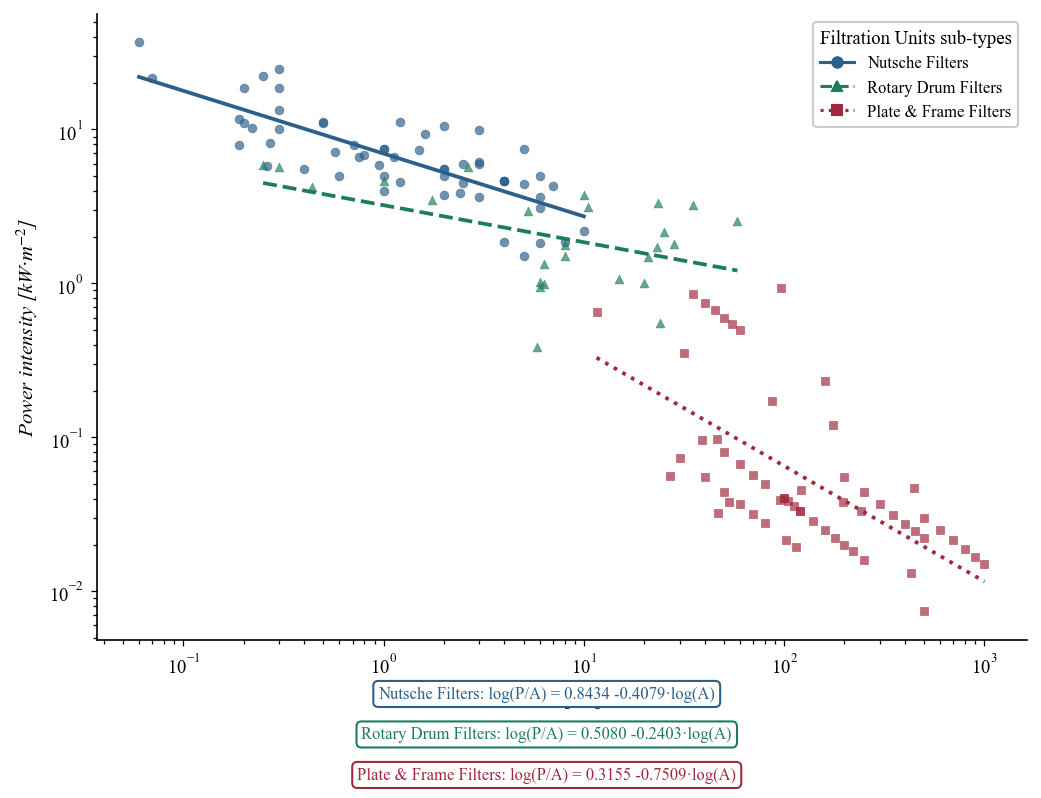

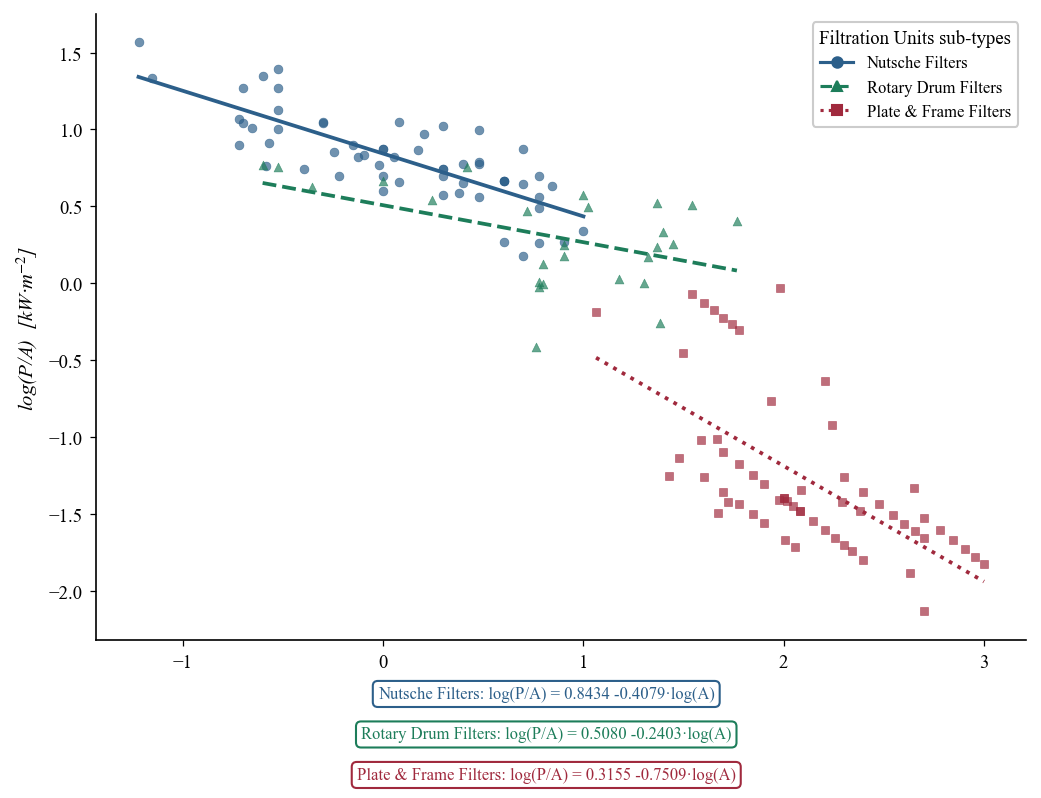

In [27]:
print("generating Figure 2b:\n")
plot_fit_multi_type_raw_unified(df=filters_clean, x_col="Area_m²", y_col="PowerToCapacity_kW·m⁻²", degrees_by_type=degrees_by_type, type_color_map=type_color_map, all_coeffs_df=all_coeffs_df_filters, equipment_type="Filtration Units", capacity_type="A")
plot_fit_multi_type(df=filters_clean, x_col="log(Capacity)", y_col="log(PowerToCapacity)", degrees_by_type=degrees_by_type, type_color_map = type_color_map, equipment_type="Filtration Units", capacity_type="A")

### ***3.4.9 Subtype vs. Pooled Model: HC3 Wald Tests (Holm-Corrected)***

Do Individual Subtypes Deviate from the Pooled Scaling Model? (HC3 Wald + Holm)

In [28]:
print("generating Table S6:\n")

df_subtype_vs_pooled = filters_clean.copy()

capacity_col = [c for c in df_subtype_vs_pooled.columns if "log(" in c and "Capacity" in c and "Power" not in c][0]
df_subtype_vs_pooled = df_subtype_vs_pooled.rename(columns={
    capacity_col:           "logA",
    "log(PowerToCapacity)": "logPa",
    "Filter Type":          "Type"
})

# Pooled HC3 fit on all data (reference coefficients)
pooled_hc3 = smf.ols("logPa ~ logA", data=df_subtype_vs_pooled).fit(cov_type="HC3")
pooled_a0  = pooled_hc3.params["Intercept"]
pooled_a1  = pooled_hc3.params["logA"]

subtype_vs_pooled_records = []
for gname in sorted(df_subtype_vs_pooled["Type"].dropna().unique()):
    df_g       = df_subtype_vs_pooled.copy()
    df_g["Ig"] = (df_g["Type"] == gname).astype(int)

    # Full model with HC3 robust covariance
    full = smf.ols("logPa ~ logA + Ig + logA:Ig", data=df_g).fit(cov_type="HC3")

    sub_a0 = full.params["Intercept"] + full.params.get("Ig",      0.0)
    sub_a1 = full.params["logA"]      + full.params.get("logA:Ig", 0.0)

    # HC3 Wald tests
    p_same      = float(full.wald_test(["Ig = 0", "logA:Ig = 0"], scalar=True).pvalue)
    p_intercept = float(full.wald_test("Ig = 0", scalar=True).pvalue)
    p_slope     = float(full.wald_test("logA:Ig = 0", scalar=True).pvalue)

    subtype_vs_pooled_records.append({
        "Subtype":      gname,
        "Pooled_a0":    round(pooled_a0, 4),
        "Pooled_a1":    round(pooled_a1, 4),
        "Subtype_a0":   round(sub_a0, 4),
        "Subtype_a1":   round(sub_a1, 4),
        "p_SameLine":   round(p_same,      4),
        "p_Intercept":  round(p_intercept, 4),
        "p_Slope_raw":  round(p_slope,     4),
    })

subtype_vs_pooled_results = (
    pd.DataFrame(subtype_vs_pooled_records)
    .sort_values("Subtype")
    .reset_index(drop=True)
)

# Holm correction across all subtype slope tests
subtype_vs_pooled_results["p_Slope_holm"] = multipletests(
    subtype_vs_pooled_results["p_Slope_raw"], method="holm"
)[1].round(4)

print("=== Subtype vs. Pooled Model (HC3 Wald + Holm) ===")
print(f"Pooled model: log(P/A) = {pooled_a0:.4f} + ({pooled_a1:.4f}) × log(A)")
print()
subtype_vs_pooled_results

generating Table S6:

=== Subtype vs. Pooled Model (HC3 Wald + Holm) ===
Pooled model: log(P/A) = 0.8040 + (-0.8990) × log(A)



,Subtype,Pooled_a0,Pooled_a1,Subtype_a0,Subtype_a1,p_SameLine,p_Intercept,p_Slope_raw,p_Slope_holm
0,Nutsche Filters,0.804,-0.899,0.8434,-0.4079,0.0,0.7817,0.0000,0.0000
1,Plate & Frame Filters,0.804,-0.899,0.3155,-0.7509,0.0,0.0671,0.0057,0.0057
2,Rotary Drum Filters,0.804,-0.899,0.5080,-0.2403,0.0,0.0006,0.0000,0.0000


### ***3.4.10 Pairwise Subtype Slope Comparison: Global and Pairwise HC3 Wald Tests (Holm-Corrected)***

Are Subtype Scaling Exponents Mutually Distinguishable? (Global + Pairwise HC3 Wald + Holm)

In [29]:
print("generating Table S7:\n")

df_pairwise = filters_clean.copy()

capacity_col = [c for c in df_pairwise.columns if "log(" in c and "Capacity" in c and "Power" not in c][0]
df_pairwise = df_pairwise.rename(columns={
    capacity_col:           "logA",
    "log(PowerToCapacity)": "logPa",
    "Filter Type":          "Type"
})

# Single interaction model with HC3 robust covariance
interaction_model = smf.ols("logPa ~ logA * C(Type)", data=df_pairwise).fit(cov_type="HC3")

# 1. Global HC3 Wald test: do any slopes differ across subtypes?
interaction_terms = [t for t in interaction_model.params.index if "logA:C(Type)" in t]
global_wald = interaction_model.wald_test(
    [f"{t} = 0" for t in interaction_terms], scalar=True
)
global_p = float(global_wald.pvalue)

print("=== Global HC3 Wald Test (slope homogeneity across subtypes) ===")
print(f"  χ² statistic : {float(global_wald.statistic):.4f}")
print(f"  p-value      : {global_p:.4f}")
print(f"  df           : {len(interaction_terms)}")
print(f"  Conclusion   : {'Slopes are NOT homogeneous (p < 0.05)' if global_p < 0.05 else 'Slopes are homogeneous — pooled model is adequate (p > 0.05)'}")
print()

# 2. Pairwise HC3 Wald contrasts with Holm correction
subtypes = sorted(df_pairwise["Type"].dropna().unique())

def get_interaction_term(subtype):
    target = f"logA:C(Type)[T.{subtype}]"
    return target if target in interaction_model.params.index else None

pairwise_records = []
raw_pvals = []

for t1, t2 in combinations(subtypes, 2):
    p1 = get_interaction_term(t1)
    p2 = get_interaction_term(t2)

    baseline_slope = interaction_model.params["logA"]
    slope_a = baseline_slope + (interaction_model.params.get(p1, 0.0) if p1 else 0.0)
    slope_b = baseline_slope + (interaction_model.params.get(p2, 0.0) if p2 else 0.0)

    if p1 is None and p2 is None:
        contrast = "0 = 0"
    elif p1 is None:
        contrast = f"{p2} = 0"
    elif p2 is None:
        contrast = f"{p1} = 0"
    else:
        contrast = f"{p1} - {p2} = 0"

    try:
        p = float(interaction_model.wald_test(contrast, scalar=True).pvalue)
    except Exception:
        p = float("nan")

    raw_pvals.append(p)
    pairwise_records.append({
        "Subtype_A":   t1,
        "Subtype_B":   t2,
        "Slope_A":     round(slope_a, 4),
        "Slope_B":     round(slope_b, 4),
        "Delta_Slope": round(slope_a - slope_b, 4),
        "p_raw":       round(p, 4),
    })

holm_pvals = multipletests(raw_pvals, method="holm")[1]

pairwise_slope_results = (
    pd.DataFrame(pairwise_records)
    .assign(p_holm=holm_pvals.round(4))
    .sort_values("p_raw")
    .reset_index(drop=True)
)

print("=== Pairwise Slope Contrasts (HC3 Wald + Holm) ===")
pairwise_slope_results

generating Table S7:

=== Global HC3 Wald Test (slope homogeneity across subtypes) ===
  χ² statistic : 16.1696
  p-value      : 0.0003
  df           : 2
  Conclusion   : Slopes are NOT homogeneous (p < 0.05)

=== Pairwise Slope Contrasts (HC3 Wald + Holm) ===


,Subtype_A,Subtype_B,Slope_A,Slope_B,Delta_Slope,p_raw,p_holm
0,Plate & Frame Filters,Rotary Drum Filters,-0.7509,-0.2403,-0.5106,0.0001,0.0002
1,Nutsche Filters,Plate & Frame Filters,-0.4079,-0.7509,0.3430,0.0033,0.0065
2,Nutsche Filters,Rotary Drum Filters,-0.4079,-0.2403,-0.1676,0.0432,0.0432


## ***3.5. Filtration Units: Grouping Analysis***

### ***3.5.1 Grouping for all Filtration Units***

In [30]:
min_group_size = 30
min_avg_difference = 2

for num_groups in [3]:
    print(f"\nTesting {num_groups} groups with ≥{min_avg_difference} average difference and ≥{min_group_size} points each:")
    total_found = test_grouping_gm(filters_clean["PowerToCapacity_kW·m⁻²"].tolist(), num_groups, min_avg_difference, min_group_size=min_group_size)
    print(f"\n🔢 Total valid groupings found: {total_found}")


Testing 3 groups with ≥2 average difference and ≥30 points each:
Valid grouping #1 (geo mean):
Splits: (0, 53, 115, 145)
Group sizes: [53, 62, 30]
Geometric means: ['7.4364', '0.4508', '0.0285']
Ratios: ['16.50x', '15.81x']
------------------------------------------------------------
Valid grouping #2 (geo mean):
Splits: (0, 54, 115, 145)
Group sizes: [54, 61, 30]
Geometric means: ['7.2483', '0.4404', '0.0285']
Ratios: ['16.46x', '15.45x']
------------------------------------------------------------
Valid grouping #3 (geo mean):
Splits: (0, 55, 115, 145)
Group sizes: [55, 60, 30]
Geometric means: ['7.0437', '0.4315', '0.0285']
Ratios: ['16.32x', '15.13x']
------------------------------------------------------------
Valid grouping #4 (geo mean):
Splits: (0, 56, 114, 145)
Group sizes: [56, 58, 31]
Geometric means: ['6.9848', '0.4327', '0.0287']
Ratios: ['16.14x', '15.07x']
------------------------------------------------------------
Valid grouping #5 (geo mean):
Splits: (0, 56, 115, 145

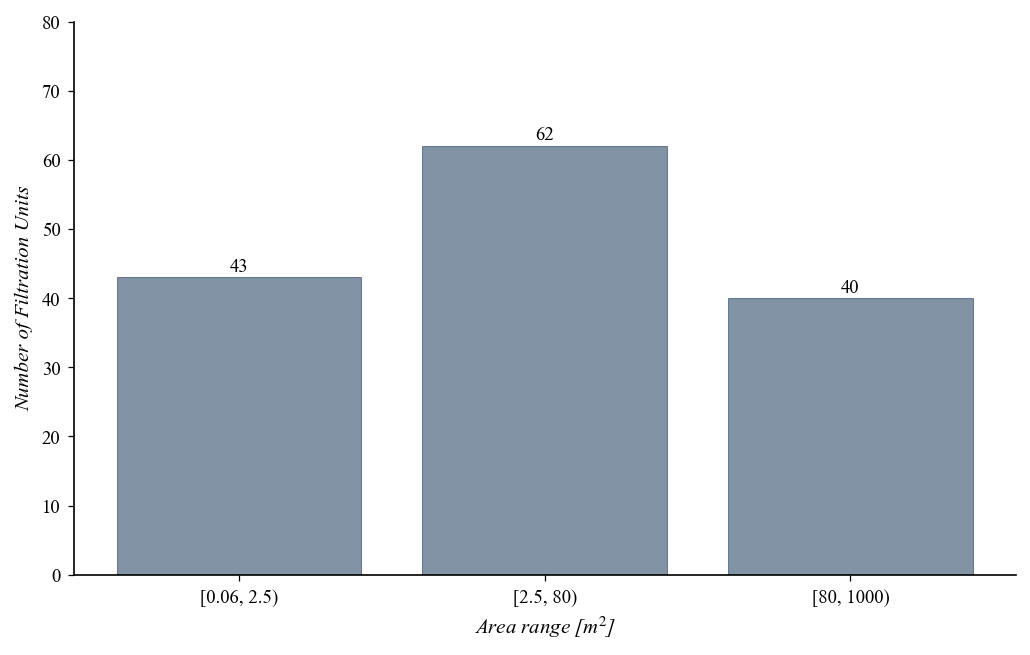

In [31]:
splits_fu = [43, 62, 40]
bin_labels_fu = ["[0.06, 2.5)", "[2.5, 80)", "[80, 1000)"]
plot_capacity_distribution(bin_labels = bin_labels_fu, counts = splits_fu , capacity_unit="Area_m²", equipment_type="Filtration Units")

generating Figure S35c:



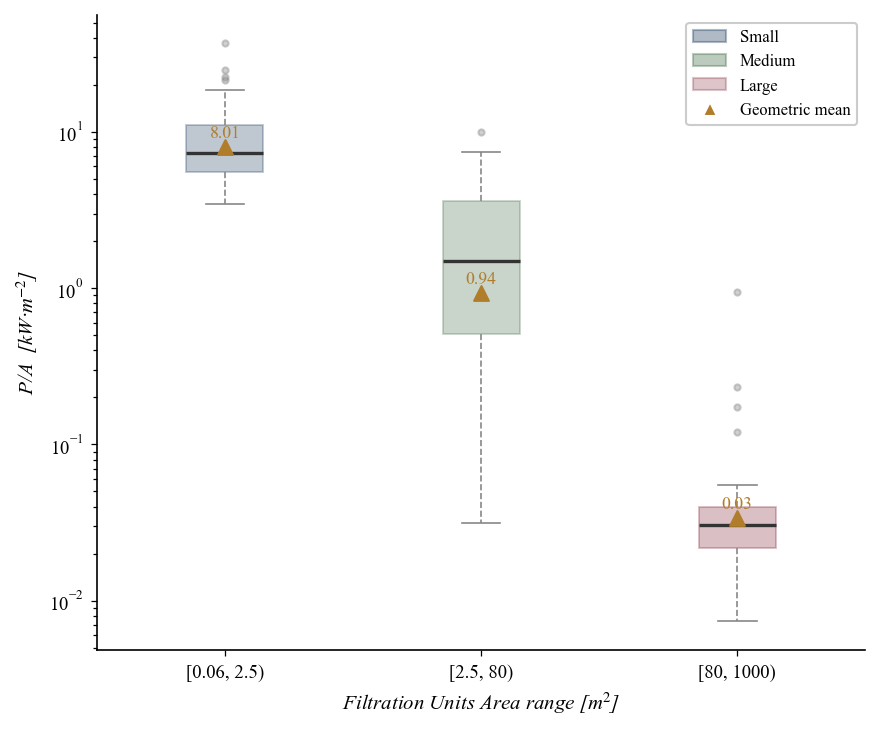

In [32]:
print("generating Figure S35c:\n")
plot_power_to_capacity_boxplot(df=filters_clean, y_col="PowerToCapacity_kW·m⁻²", splits=splits_fu, bin_labels=bin_labels_fu, capacity_unit="Area_m²", equipment_type="Filtration Units")

In [33]:
print("generating Table S18:\n")

labels = {"Group 1": "Small", "Group 2": "Medium", "Group 3": "Large"}
results = anova_tukey(y = filters_clean["log(PowerToCapacity)"], splits = splits_fu, group_labels = labels)

print("\nANOVA Results:")
display(results["ANOVA"])     

print("\nTukey HSD Results:")
display(results["Tukey_standard"])

print("\nLog-space-adjusted Tukey HSD (geometric means):")
display(results["Tukey_table"])  

generating Table S18:


ANOVA Results:


,F-statistic,p-value,Significant (α=0.05)
0,211.66583,2.505749e-43,True



Tukey HSD Results:


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Small,Medium,-0.9322,0.0,-1.1805,-0.6838,True
1,Small,Large,-2.3719,0.0,-2.6468,-2.0970,True
2,Medium,Large,-1.4397,0.0,-1.6935,-1.1859,True



Log-space-adjusted Tukey HSD (geometric means):


,group1,group2,GM group1,GM group2,GM ratio,Lower 95% CI,Upper 95% CI,p-adj,Significant (α=0.05)
0,Small,Medium,8.012441,0.936704,0.116896,0.065993,0.207109,0.0,True
1,Small,Large,8.012441,0.034032,0.004247,0.002255,0.007998,0.0,True
2,Medium,Large,0.936704,0.034032,0.036333,0.020253,0.065178,0.0,True


generating Table Sx
Group 1: n=43, bins=11


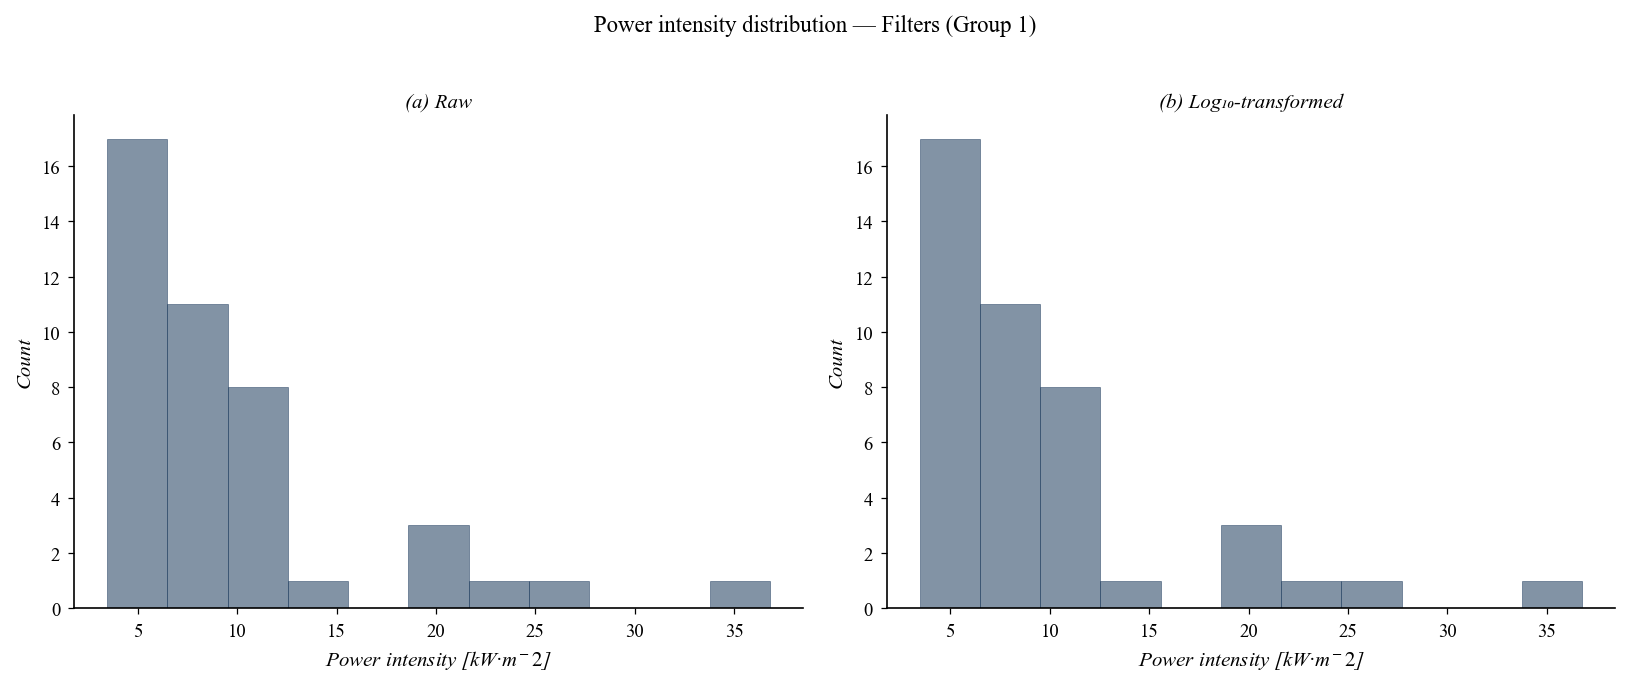

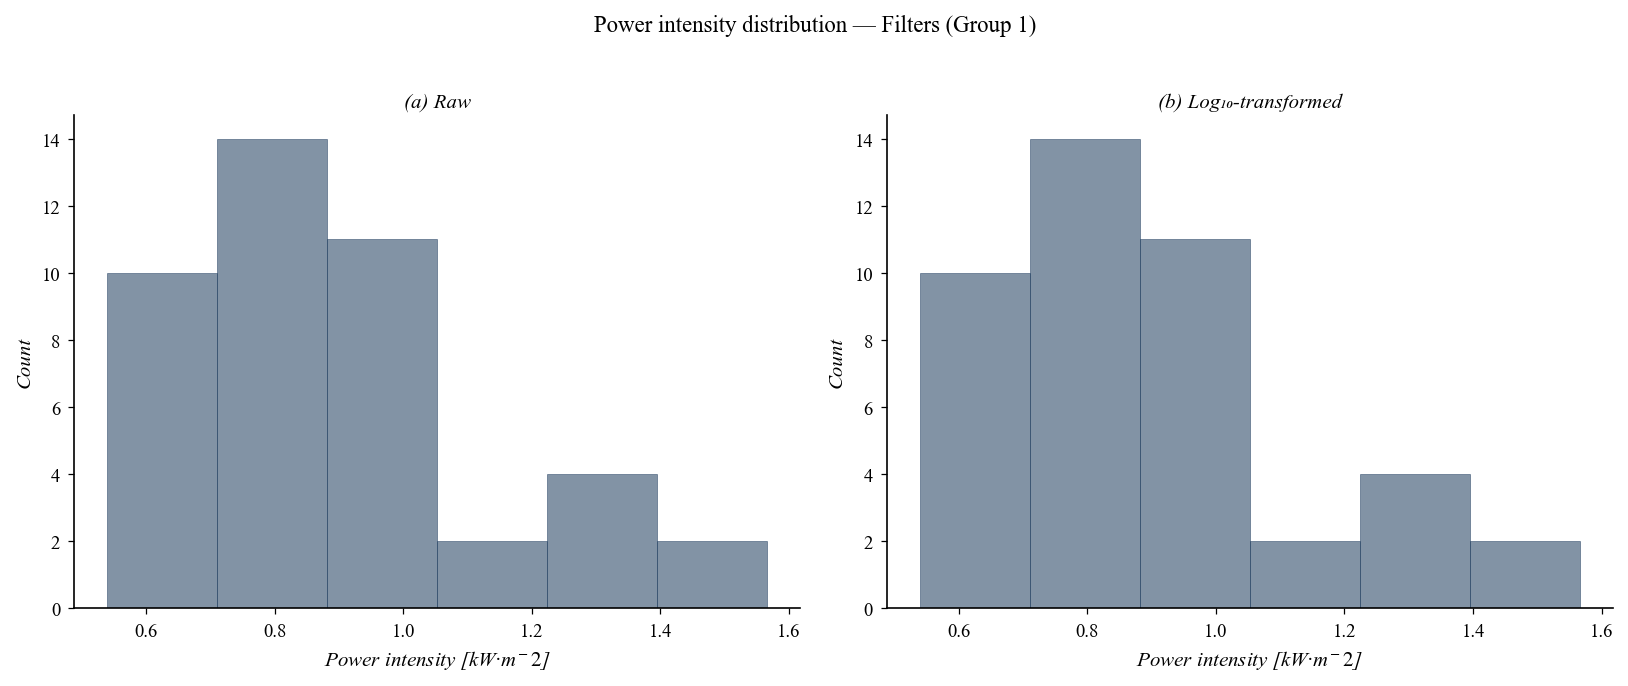


Kolmogorov–Smirnov Test Results for Group 1:
  Distribution  KS Statistic       p-value
0   Log-normal        0.0586  9.965659e-01
1       Normal        0.2153  3.143446e-02
2   Triangular        0.3760  5.704762e-06
3      Uniform        0.5877  1.146026e-14 

Group 2: n=62, bins=7


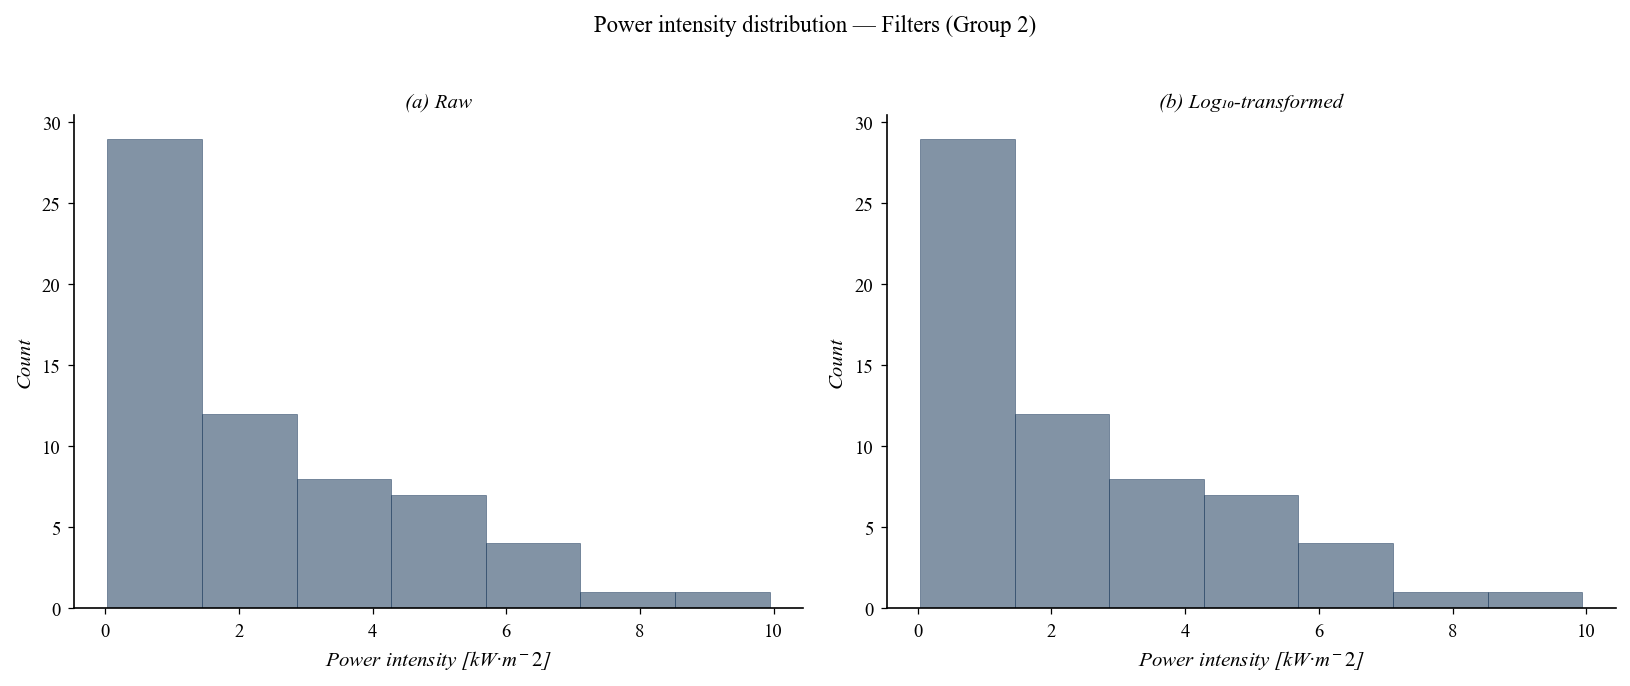

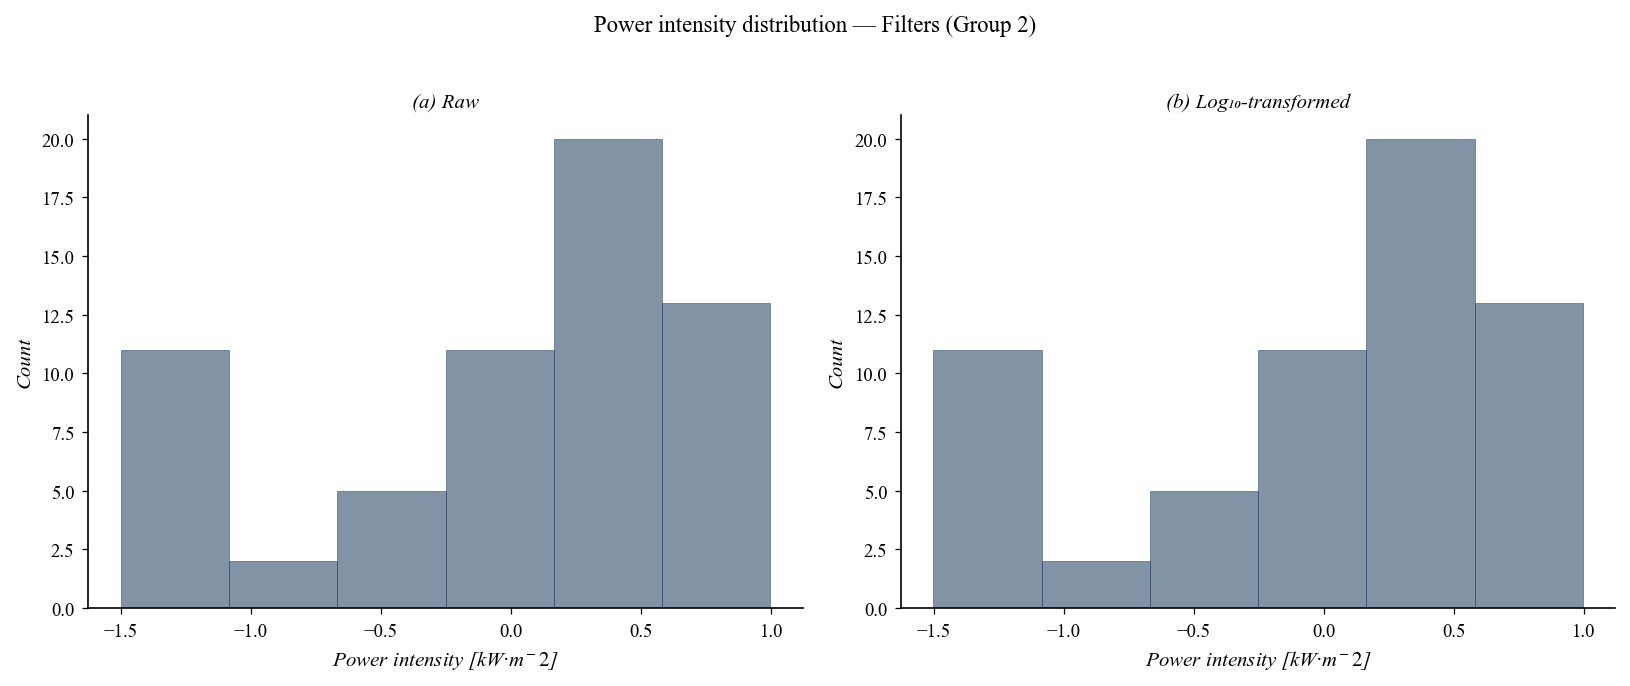


Kolmogorov–Smirnov Test Results for Group 2:
  Distribution  KS Statistic       p-value
0   Log-normal        0.1599  7.494158e-02
1       Normal        0.1718  4.538132e-02
2   Triangular        0.2841  6.392173e-05
3      Uniform        0.4280  7.917780e-11 

Group 3: n=40, bins=87


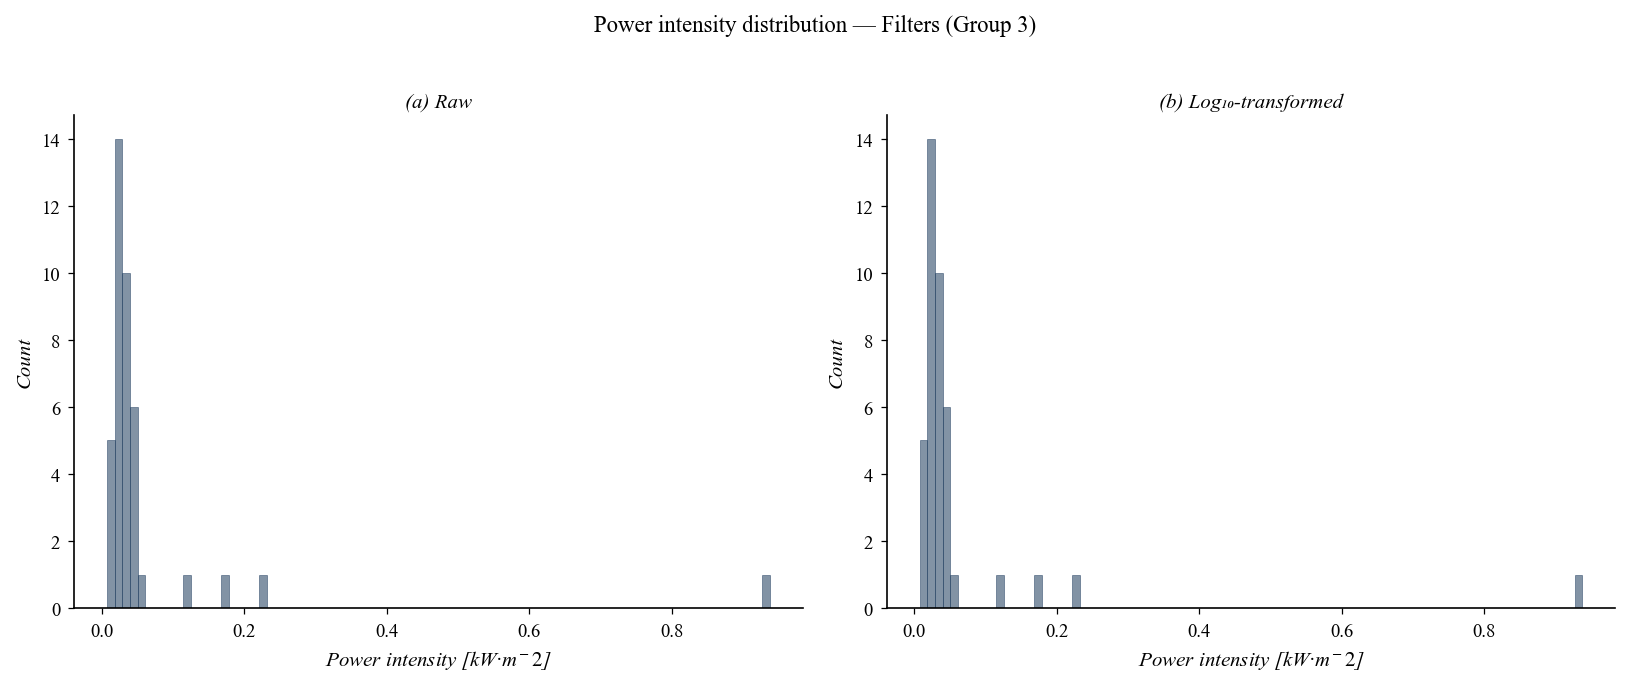

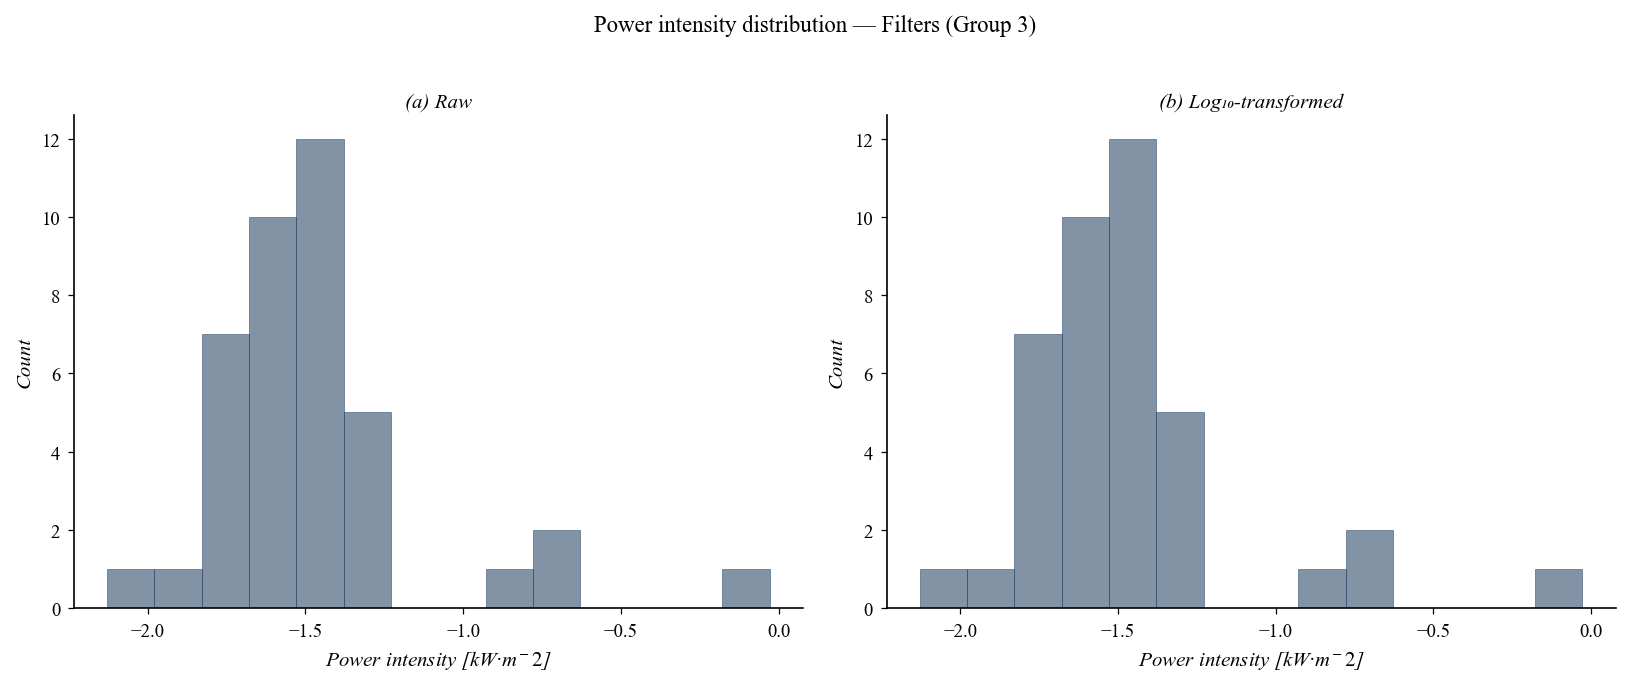


Kolmogorov–Smirnov Test Results for Group 3:
  Distribution  KS Statistic       p-value
0   Log-normal        0.1784  1.383457e-01
1       Normal        0.4219  5.676719e-07
2   Triangular        0.8020  3.049273e-28
3      Uniform        0.8488  3.630107e-33 



In [34]:
print("generating Table Sx")
indices = np.cumsum([0] + splits_fu).tolist()
ks_results_fu_groups = {}

for i in range(len(splits_fu)):
    start, end = indices[i], indices[i+1]
    subset = filters_clean.iloc[start:end]
    # Freedman–Diaconis bins
    bins = freedman_diaconis_bins(subset["PowerToCapacity_kW·m⁻²"])
    print(f"Group {i+1}: n={len(subset)}, bins={bins}")
    
    # Plot histogram
    plot_pv_histogram(df = subset, column_name = "PowerToCapacity_kW·m⁻²", equipment = f"Filters (Group {i+1})", unit = "[kW·m⁻²]", bins = bins)
    plot_pv_histogram(df = subset, column_name = "log(PowerToCapacity)", equipment = f"Filters (Group {i+1})", unit = "" , bins = bins)
    # Call your existing KS test function
    ks_df = distribution_kolmogorov_smirnov_tests(subset["PowerToCapacity_kW·m⁻²"])

    print(f"\nKolmogorov–Smirnov Test Results for Group {i+1}:")
    print(ks_df, '\n')

In [35]:
print("generating Table S15:\n")
grouped_results_fu = summarize_geo_stats(df=filters_clean.copy(), y_col="PowerToCapacity_kW·m⁻²", splits=splits_fu, bin_labels=bin_labels_fu, capacity_unit="Area_m²", equipment_type="Filtration Units")

grouped_results_fu

generating Table S15:



,Equipment,"Area bin, m²",GeometricMean,GeometricStd,"Interval [GM/GSD, GM*GSD]",95% CI for GM,Smearing factor
0,Filtration Units,"[0.06, 2.5)",8.012,1.746,"[4.590, 13.987]","[6.750, 9.511]",1.1679
1,Filtration Units,"[2.5, 80)",0.937,5.307,"[0.177, 4.971]","[0.613, 1.431]",4.0258
2,Filtration Units,"[80, 1000)",0.034,2.305,"[0.015, 0.078]","[0.026, 0.044]",1.4172


In [40]:
print("generating Table S15:\n")
grouped_results_all = []  

for subtype in filters_clean["Type"].unique():
    df_sub = filters_clean[filters_clean["Type"] == subtype].copy()
    
    grouped_results_sub = summarize_geo_stats(
        df=df_sub,
        y_col="PowerToCapacity_kW·m⁻²",
        splits=splits_fu,
        bin_labels=bin_labels_fu,
        capacity_unit="Area_m²",
        equipment_type=subtype  
    )

    grouped_results_all.append(grouped_results_sub)


grouped_results_mixers_all = pd.concat(grouped_results_all, ignore_index=True)

grouped_results_mixers_all


generating Table S15:



,Equipment,"Area bin, m²",Count (n),GeometricMean,GeometricStd,95% PI,95% CI for GM,Smearing factor
0,Nutsche Filters,"[0.06, 2.5)",38,8.598,1.734,"[2.858, 25.866]","[7.175, 10.305]",1.1637
1,Nutsche Filters,"[2.5, 80)",20,3.885,1.673,"[1.388, 10.875]","[3.054, 4.943]",1.1416
2,Rotary Drum Filters,"[0.06, 2.5)",5,4.686,1.243,"[3.034, 7.238]","[3.577, 6.138]",1.0239
3,Rotary Drum Filters,"[2.5, 80)",21,1.662,1.940,"[0.442, 6.258]","[1.229, 2.248]",1.2456
4,Plate & Frame Filters,"[2.5, 80)",21,0.136,3.445,"[0.011, 1.616]","[0.078, 0.239]",2.1493
5,Plate & Frame Filters,"[80, 1000)",40,0.034,2.305,"[0.006, 0.181]","[0.026, 0.044]",1.4172


### ***3.5.2 Grouping per Equipment Type***

generating Figure S37:



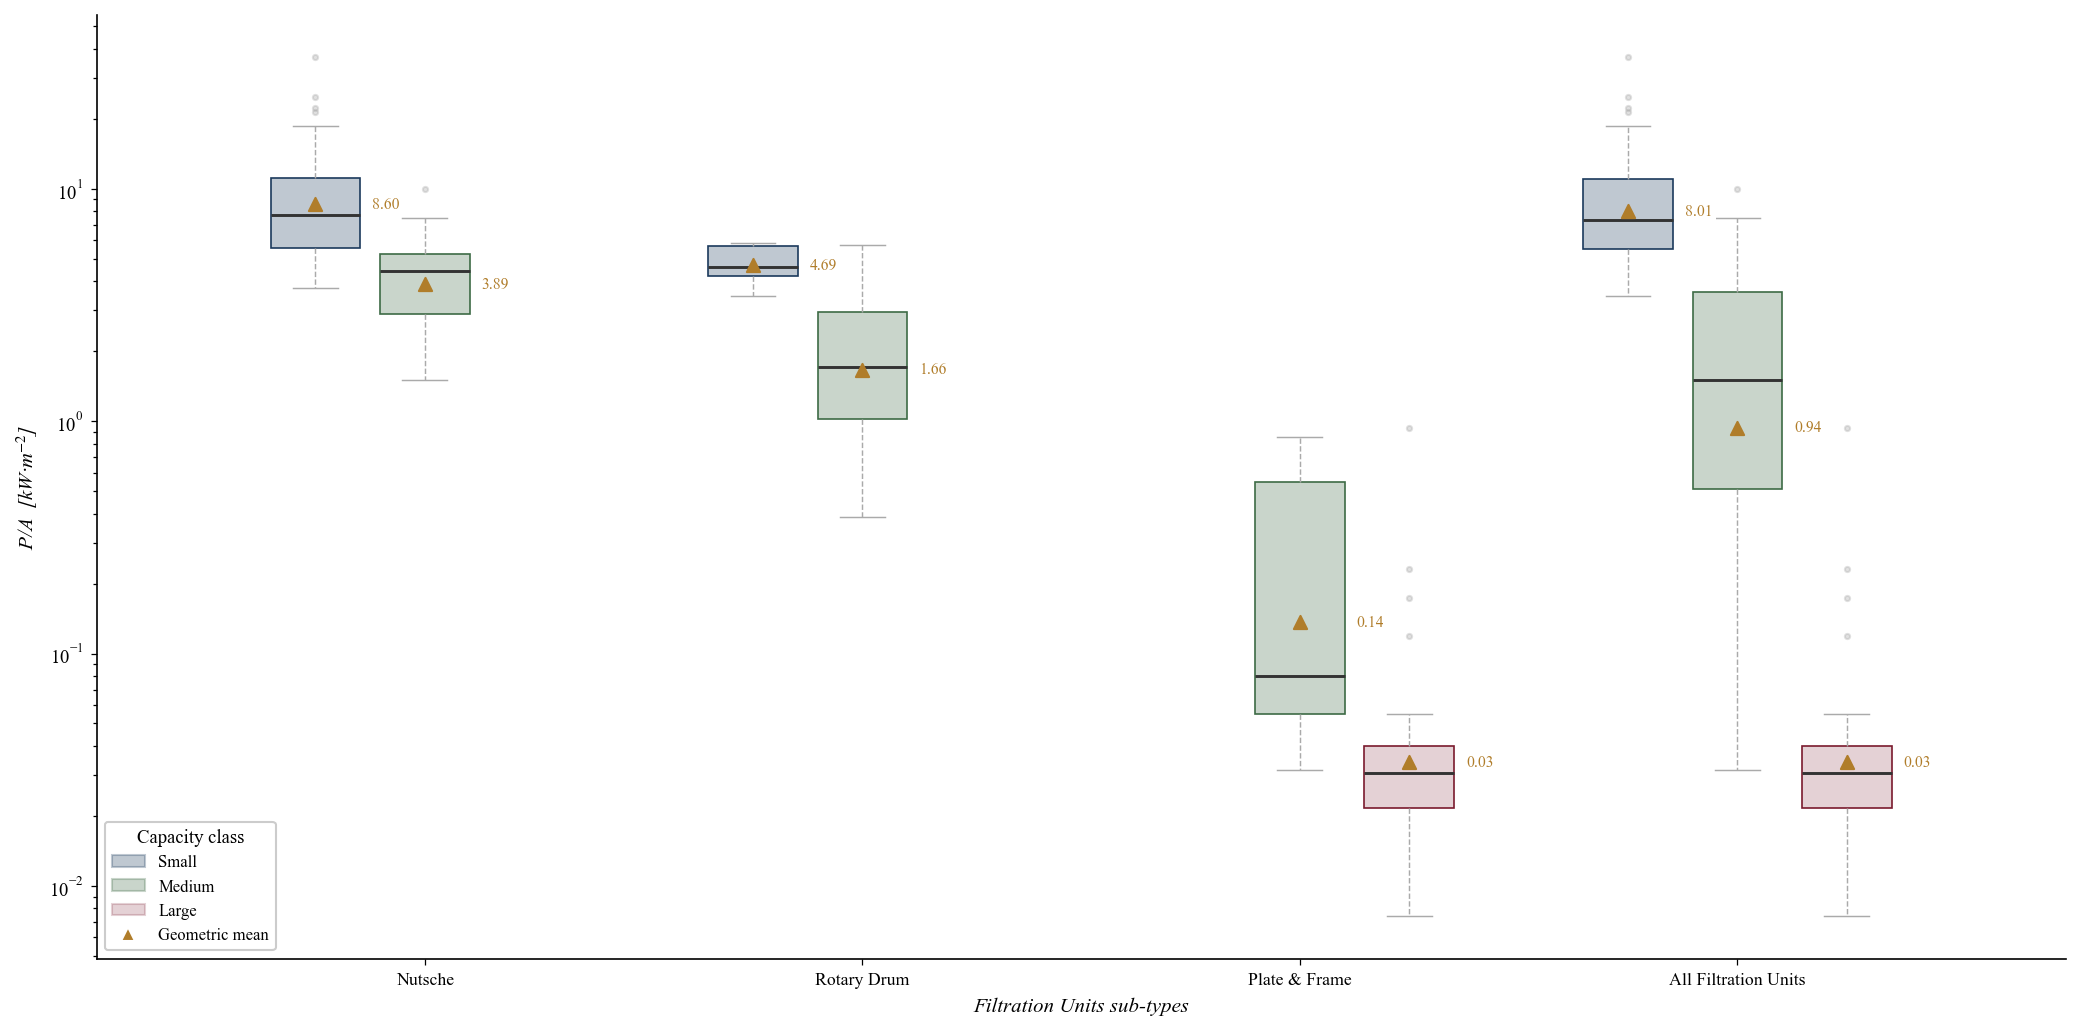

In [38]:
print("generating Figure S37:\n")
plot_subtype_boxplots_grouped(df=filters_clean, y_col="PowerToCapacity_kW·m⁻²", equipment_col="Type", splits=splits_fu, bin_labels=["Small", "Medium", "Large"], capacity_unit="Area_m²", equipment_type="Filtration Units")

## ***3.5.3 GSD per Sub-type per Size Bin***

In [41]:
print("generating Table S15:\n")
### ***3.5.3 GSD per Sub-type per Size Bin***

import numpy as np
import pandas as pd
from scipy.stats import t as t_dist

def gsd_by_subtype_bin(df, y_col, equipment_col, capacity_col, splits, bin_labels):
    """
    Compute GSD (and supporting stats) of power-to-capacity for each
    equipment sub-type within each size bin (Small / Medium / Large).

    Parameters
    ----------
    df          : DataFrame (sorted by capacity, same order used for splits)
    y_col       : str  – power-to-capacity column
    equipment_col : str – sub-type column
    splits      : list[int] – number of rows in each bin
    bin_labels  : list[str] – human-readable bin names

    Returns
    -------
    DataFrame with columns:
        Bin | Sub-type | n | GM [kW·m⁻²] | GSD | GM/GSD | GM×GSD | 95% CI Low | 95% CI High
    """
    records = []
    indices = np.cumsum([0] + splits).tolist()

    for i, label in enumerate(bin_labels):
        start, end = indices[i], indices[i + 1]
        bin_df = df.iloc[start:end]

        # Overall row for the bin
        for subtype, grp in bin_df.groupby(equipment_col):
            vals = grp[y_col].values
            vals = vals[vals > 0]
            n = len(vals)
            cap_vals = grp[capacity_col].values
            cap_min  = round(float(np.nanmin(cap_vals)), 4)
            cap_max  = round(float(np.nanmax(cap_vals)), 4)
            if n < 2:
                records.append({
                    "Bin": label, "Sub-type": subtype,
                    "n": n, "Min [m²]": cap_min, "Max [m²]": cap_max,"GM [kW·m⁻²]": np.nan,
                    "GSD": np.nan, "GM/GSD": np.nan, "GM×GSD": np.nan,
                    "95% CI Low": np.nan, "95% CI High": np.nan
                })
                continue

            logv  = np.log10(vals)
            gm    = 10 ** np.mean(logv)
            gsd   = 10 ** np.std(logv, ddof=1)
            se    = np.std(logv, ddof=1) / np.sqrt(n)
            tc    = t_dist.ppf(0.975, df=n - 1)
            ci_lo = 10 ** (np.mean(logv) - tc * se)
            ci_hi = 10 ** (np.mean(logv) + tc * se)

            records.append({
                "Bin": label,
                "Sub-type": subtype,
                "n": n,
                "Min [m²]": cap_min,
                "Max [m²]": cap_max,
                "GM [kW·m⁻²]": round(gm,  4),
                "GSD":          round(gsd, 4),
                "GM/GSD":       round(gm / gsd, 4),
                "GM×GSD":       round(gm * gsd, 4),
                "95% CI Low":   round(ci_lo, 4),
                "95% CI High":  round(ci_hi, 4),
            })

    result = pd.DataFrame(records)
    # Bin order
    result["Bin"] = pd.Categorical(result["Bin"], categories=bin_labels, ordered=True)
    result = result.sort_values(["Bin", "Sub-type"]).reset_index(drop=True)
    return result


gsd_subtype_bin_fu = gsd_by_subtype_bin(
    df=filters_clean,
    y_col="PowerToCapacity_kW\u00b7m\u207b\u00b2",
    equipment_col="Type",
    capacity_col="Area_m²",
    splits=splits_fu,
    bin_labels=["Small", "Medium", "Large"]
)

print("GSD of Power-to-Capacity by Sub-type and Size Bin – Filtration Units")
gsd_subtype_bin_fu


generating Table S15:

GSD of Power-to-Capacity by Sub-type and Size Bin – Filtration Units


,Bin,Sub-type,n,Min [m²],Max [m²],GM [kW·m⁻²],GSD,GM/GSD,GM×GSD,95% CI Low,95% CI High
0,Small,Nutsche Filters,38,0.06,2.40,8.5984,1.7344,4.9575,14.9133,7.1748,10.3045
1,Small,Rotary Drum Filters,5,0.25,1.75,4.6859,1.2428,3.7703,5.8238,3.5773,6.1379
2,Medium,Nutsche Filters,20,2.50,10.00,3.8853,1.6730,2.3224,6.5001,3.0537,4.9434
3,Medium,Plate & Frame Filters,21,11.56,70.00,0.1362,3.4455,0.0395,0.4691,0.0775,0.2391
4,Medium,Rotary Drum Filters,21,2.63,58.37,1.6624,1.9401,0.8569,3.2253,1.2295,2.2478
5,Large,Plate & Frame Filters,40,80.00,1000.00,0.0340,2.3049,0.0148,0.0784,0.0261,0.0444


## ***3.6. Filtration Units: Capacity Range Summary (Before & After Outlier Removal)***

In [42]:
def capacity_range_summary(df_raw, df_clean, capacity_col, equipment_col, equipment_type):
    """
    Produce a min–max capacity summary table for the overall equipment class
    and each sub-type, before and after outlier removal.

    Parameters
    ----------
    df_raw      : DataFrame before outlier removal
    df_clean    : DataFrame after outlier removal
    capacity_col: str  – column holding the capacity values (e.g. 'Area_m²')
    equipment_col: str – sub-type column (e.g. 'Type')
    equipment_type: str – human label for the equipment class

    Returns
    -------
    DataFrame with multi-level columns: Before Removal | After Removal
    """
    rows = []

    def stats(df, label):
        v = df[capacity_col].dropna()
        return {
            "Equipment": label,
            "n (before)": len(df_raw[df_raw[equipment_col] == label]) if label != equipment_type else len(df_raw),
            "Min (before) [m²]": None,  # filled below
            "Max (before) [m²]": None,
            "n (after)": len(v),
            "Min (after) [m²]": round(v.min(), 4) if len(v) else np.nan,
            "Max (after) [m²]": round(v.max(), 4) if len(v) else np.nan,
        }

    # Overall
    all_subtypes = sorted(df_raw[equipment_col].unique())

    # Build rows: first overall, then per subtype
    for label, df_r, df_c in (
        [(equipment_type, df_raw, df_clean)] +
        [(st, df_raw[df_raw[equipment_col]==st], df_clean[df_clean[equipment_col]==st])
         for st in all_subtypes]
    ):
        r_vals = df_r[capacity_col].dropna()
        c_vals = df_c[capacity_col].dropna()
        rows.append({
            "Equipment / Sub-type": label,
            "n (before)": len(r_vals),
            "Min [m²] (before)": round(r_vals.min(), 4) if len(r_vals) else np.nan,
            "Max [m²] (before)": round(r_vals.max(), 4) if len(r_vals) else np.nan,
            "n (after)": len(c_vals),
            "Min [m²] (after)": round(c_vals.min(), 4) if len(c_vals) else np.nan,
            "Max [m²] (after)": round(c_vals.max(), 4) if len(c_vals) else np.nan,
            "Outliers Removed": len(r_vals) - len(c_vals),
        })

    return pd.DataFrame(rows)


capacity_summary_fu = capacity_range_summary(
    df_raw=filters_raw,
    df_clean=filters_clean,
    capacity_col="Area_m\u00b2",
    equipment_col="Type",
    equipment_type="Filtration Units"
)

print("Capacity Range Summary – Filtration Units")
capacity_summary_fu


Capacity Range Summary – Filtration Units


,Equipment / Sub-type,n (before),Min [m²] (before),Max [m²] (before),n (after),Min [m²] (after),Max [m²] (after),Outliers Removed
0,Filtration Units,152,0.06,1000.00,145,0.06,1000.00,7
1,Nutsche Filters,60,0.06,10.00,58,0.06,10.00,2
2,Plate & Frame Filters,64,8.70,1000.00,61,11.56,1000.00,3
3,Rotary Drum Filters,28,0.25,78.79,26,0.25,58.37,2


generating Figure S44c:



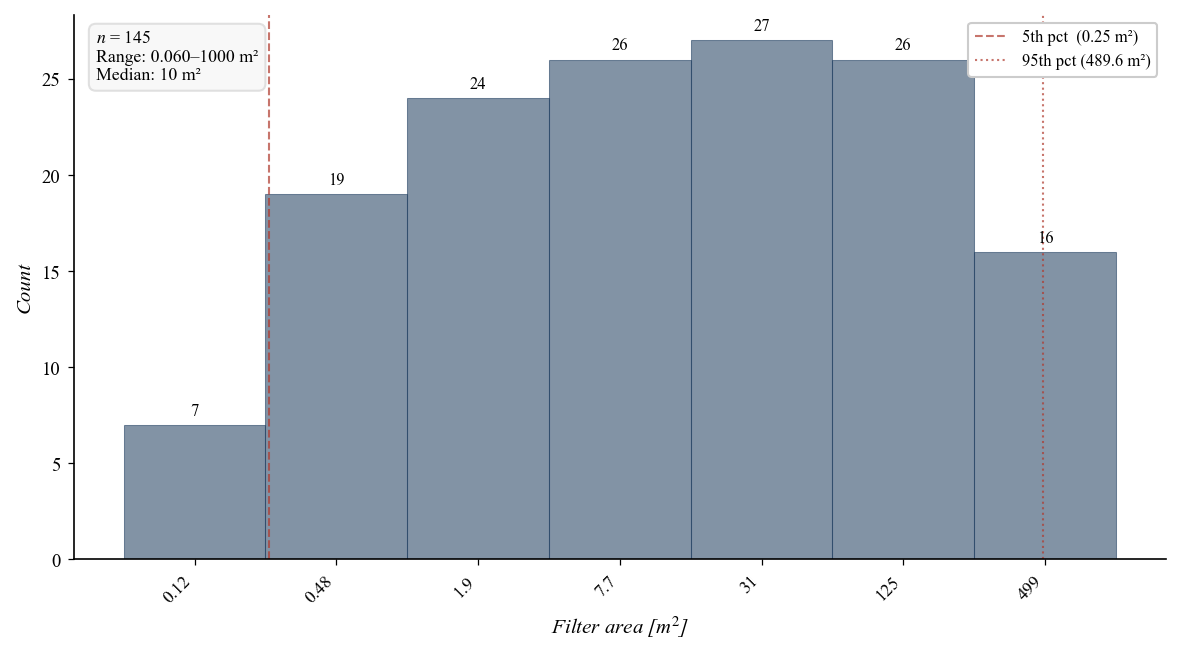

=== Capacity distribution summary — Filtration Units (post-outlier removal) ===
  n                : 145
  Min              : 0.0600 m²
  Max              : 1000.00 m²
  Median           : 10.000 m²
  5th percentile   : 0.2500 m²
  95th percentile  : 489.57 m²
  Peak bin (mode)  : ~31 m²  (n = 27)
  FD bins used     : 7


In [43]:
print("generating Figure S44c:\n")
## Capacity Size Distribution — Vendor Dataset Coverage (after outlier removal)
# Used for equipment energy estimation
# Shows that vendor listings are concentrated in mid-range commercial sizes,
# with tails (very small and very large equipment) thinly sampled.

# ── 1. Data preparation ──────────────────────────────────────────────────────
areas = filters_clean["Area_m²"].dropna().values
log_areas = np.log10(areas)

# ── 2. Bin width: Freedman–Diaconis on log10(A) ──────────────────────────────
# Applied on log scale to respect lognormal distribution of capacity data.
n_bins = freedman_diaconis_bins(log_areas)
bin_edges_log = np.linspace(log_areas.min(), log_areas.max(), n_bins + 1)
bin_edges_raw = 10 ** bin_edges_log

counts, _ = np.histogram(log_areas, bins=bin_edges_log)

# ── 3. Bin centers and labels ─────────────────────────────────────────────────
bin_centers_log = 0.5 * (bin_edges_log[:-1] + bin_edges_log[1:])
bin_centers_raw = 10 ** bin_centers_log

def _fmt_area(v):
    if v < 0.1:    return f"{v:.3f}"
    elif v < 1:    return f"{v:.2f}"
    elif v < 10:   return f"{v:.1f}"
    else:          return f"{v:.0f}"

tick_labels = [_fmt_area(v) for v in bin_centers_raw]

# ── 4. Identify peak bin (mode) for annotation ───────────────────────────────
peak_idx   = np.argmax(counts)
peak_count = counts[peak_idx]
peak_area  = bin_centers_raw[peak_idx]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    bin_centers_log,
    counts,
    width=np.diff(bin_edges_log),
    color=OBS_COLOR,
    alpha=0.55,
    edgecolor=OBS_COLOR,
    linewidth=0.5,
    align="center",
)

# Count labels on top of each bar
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(count),
            ha="center", va="bottom",
            fontsize=8, color="black",
        )

# Vertical dashed lines at dataset tails (5th and 95th percentile of log A)
p5  = np.percentile(log_areas, 5)
p95 = np.percentile(log_areas, 95)
ax.axvline(p5,  color="#B03A2E", linewidth=1.0, linestyle="--", alpha=0.7,
           label=f"5th pct  ({10**p5:.2f} m²)")
ax.axvline(p95, color="#B03A2E", linewidth=1.0, linestyle=":",  alpha=0.7,
           label=f"95th pct ({10**p95:.1f} m²)")

# ── 6. Axes formatting ────────────────────────────────────────────────────────
ax.set_xticks(bin_centers_log)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8.5)
ax.set_xlabel("Filter area [m$^2$]", style="italic", fontsize=10)
ax.set_ylabel("Count", style="italic", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=8, frameon=True, facecolor="white",
          edgecolor="#cccccc", loc="upper right")

# Summary stats text box
n_total = len(areas)
a_min   = areas.min()
a_max   = areas.max()
a_med   = np.median(areas)
ax.text(
    0.02, 0.97,
    f"$n$ = {n_total}\n"
    f"Range: {_fmt_area(a_min)}–{_fmt_area(a_max)} m²\n"
    f"Median: {_fmt_area(a_med)} m²",
    transform=ax.transAxes,
    fontsize=8.5, color="black",
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8f8f8",
              edgecolor="#dddddd", alpha=0.9),
)

plt.tight_layout()
plt.show()

# ── 7. Numerical summary ──────────────────────────────────────────────────────
print("=== Capacity distribution summary — Filtration Units (post-outlier removal) ===")
print(f"  n                : {n_total}")
print(f"  Min              : {a_min:.4f} m²")
print(f"  Max              : {a_max:.2f} m²")
print(f"  Median           : {a_med:.3f} m²")
print(f"  5th percentile   : {10**p5:.4f} m²")
print(f"  95th percentile  : {10**p95:.2f} m²")
print(f"  Peak bin (mode)  : ~{_fmt_area(peak_area)} m²  (n = {peak_count})")
print(f"  FD bins used     : {n_bins}")